# Mini-projet 2 – Conditional Variational Autoencoders (CVAE)

Dans ce mini-projet, nous étudions les autoencodeurs variationnels conditionnels (*Conditional Variational Autoencoders*, ou **CVAEs**), qui constituent une extension du cadre des autoencodeurs variationnels standards (*Variational Autoencoders*, ou VAEs). Cette extension permet de conditionner la génération de données sur des informations supplémentaires, telles que des étiquettes de classe.

L’objectif principal de ce projet est de concevoir, implémenter et entraîner un modèle de CVAE, puis de l’appliquer au jeu de données Fashion-MNIST. En intégrant l’information de classe à la fois dans l’encodeur et dans le décodeur, le CVAE permet une génération contrôlée des données, rendant possible la production d’échantillons correspondant à des classes spécifiques.

Tout au long de ce projet, nous présentons les fondements théoriques des VAEs et de leur extension conditionnelle, justifions les choix architecturaux et les hyperparamètres utilisés, analysons les différents termes de la fonction de perte, et évaluons la qualité de l’espace latent appris à l’aide de visualisations et d’échantillons générés.

La section suivante est consacrée au cadre théorique nécessaire à la compréhension des autoencodeurs variationnels ainsi que de leur version conditionnelle.


## I. Cadre théorique – Autoencodeurs variationnels et conditionnels



### 1. De l’autoencodeur (AE) au Variational Autoencoder (VAE)


#### 1.1 Autoencodeur classique

Un autoencodeur est constitué de deux composantes principales :

- un **encodeur**, qui projette une observation $x$ dans un espace latent de dimension réduite, noté $z$ ;
- un **décodeur**, qui reconstruit une approximation $\hat{x}$ de l’entrée originale à partir de cette représentation latente.

Le modèle est entraîné de manière à ce que la reconstruction $\hat{x}$ soit aussi proche que possible de $x$. Une fonction de perte couramment utilisée est l’erreur quadratique moyenne (MSE)

$$
\mathcal{L}_{AE}(x) = \|x - \hat{x}\|^2.
$$

Les autoencodeurs permettent ainsi d’apprendre des représentations compactes des données. Toutefois :

- aucune contrainte n’est imposée sur la structure de l’espace latent ;
- le modèle n’est pas véritablement génératif : un point $z$ tiré arbitrairement dans l’espace latent n’est pas garanti de produire une observation réaliste.




#### 1.2 Vers un espace latent probabiliste : le VAE

Le Variational Autoencoder (VAE) introduit une idée fondamentale :  
l’encodeur ne produit plus un vecteur latent déterministe, mais un ensemble de paramètres qui caractérisent la distribution de la variable latente, in our case une distribution normale multivariée, i.e, pour chaque observation $x$, l’encodeur paramétrise une distribution latente de la forme
$$
q_\phi(z \mid x) = \mathcal{N}\big(\mu(x),\, \sigma^2(x) I\big), \quad
\text{ où $\mu(x)$ et $\sigma(x)$ sont des les sorties de l'encodeur, $x$ étant l'entrée, $z$ la variable latente, et $\phi$ les paramètres de l'encodeur.} 
$$

Afin que le modèle puisse calculer des gradients sur $\mu(x)$ and $\sigma(x)$, on utilise le **trick de reparamétrisation**
$$
z = \mu(x) + \sigma(x)\,\varepsilon, \qquad \varepsilon \sim \mathcal{N}(0, I).
$$

Le décodeur lui apprend une distribution de $x$ (variable entrée) conditionnelle de $z$ (variable latente), notée $p_\theta(x \mid z)$.

L’entraînement du VAE repose sur la maximisation de la **borne inférieure de la vraisemblance marginale** (*Evidence Lower Bound*, ELBO), nous nous informons à partir de cet article: https://beckham.nz/2023/04/27/conditional-vaes.html. En pratique, on minimise la loss négative suivante
$$
\mathcal{L}_{VAE}(x)
= - \mathbb{E}_{q_\phi(z \mid x)}\big[\log p_\theta(x \mid z)\big]
+ \mathrm{KL}\big(q_\phi(z \mid x)\,\|\,p(z)\big),
$$

où $p(z) = \mathcal{N}(0, I)$ est le prior sur les variables latentes.

Le premier terme correspond à la distance entre reconstruction et entrée originale, tandis que le second terme régularise l’espace latent en forçant les distributions latentes à rester proches du prior. Cette régularisation permet d’éviter le surapprentissage et garantit que la variable latente suit une distribution connue, à partir de laquelle on peut échantillonner, puis générer de nouvelles images. Dans notre cas, la variable latente suit une distribution normale multivariée centrée réduite $z \sim \mathcal{N}(0, I).$



### 2. Le Conditional Variational Autoencoder (CVAE)

Un VAE classique permet de générer de nouvelles images, mais **sans aucun contrôle sur la classe produite**.  
Par exemple, en échantillonnant un vecteur latent $z \sim \mathcal{N}(0, I)$, il n’est pas possible d’imposer au modèle de générer spécifiquement une chaussure, un pantalon ou un pull.

Le Conditional Variational Autoencoder (CVAE) répond à cette limitation en introduisant une **variable de conditionnement** $y$, telle que la classe associée à l’image.



#### 2.1 Principe du CVAE

Dans un CVAE, l’encodeur et le décodeur sont tous deux **conditionnés par le label $y$**, en plus de l’image $x$.

- L’encodeur apprend une distribution latente conditionée par $x$ (l'entrée) et $y$ (variable de conditionnement, le label dans notre cas) 
$$
q_\phi(z \mid x, y).
$$

- Le décodeur apprend la distribution conditionnelle de $x$ (l'entrée) sachant $z$ (la variable latente) et $y$ (le label)
$$
p_\theta(x \mid z, y).
$$

Dans le cas du jeu de données **Fashion-MNIST**, le label $y$ est généralement représenté sous la forme d’un **vecteur one-hot** de dimension 10, correspondant aux différentes classes.




#### 2.2 Intérêt du conditionnement sur $y$

Dans un VAE classique, la variable latente $z$ doit capturer simultanément :

- l’information inter-classe (pantalon, chaussure, etc.) ;
- les variations intra-classe (style, forme, épaisseur, orientation).

Dans un CVAE, la classe $y$ étant fournie explicitement au modèle, **la variable latente $z$ n’a plus besoin d’encoder l’information inter-classe**.  Elle se concentre uniquement sur les variations fines *au sein d’une même classe*.

Ce découplage entraîne plusieurs avantages :
- un espace latent plus **structuré** et plus **interprétable** ;
- une génération **contrôlée** par la classe ;
- une stabilité accrue lors de l’entraînement.



#### 2.3 Génération conditionnelle

Une fois le modèle entraîné, la génération d’une image d'une classe $y$ spécifique s’effectue en deux étapes :
1. échantillonner un vecteur latent $z \sim \mathcal{N}(0, I)$
2. fournir le couple $(z, y)$ au décodeur

$$
\hat{x} = \text{Decoder}(z, y).
$$

Le modèle génère alors une image réaliste (si le modèle est bien entraîné) appartenant à la classe $y$, dont le style est fourni par le vecteur latent $z$.



#### 2.4 Fonction de perte du CVAE et pondération du terme KL
Comme pour le VAE, l’apprentissage du CVAE repose sur la maximisation d’une borne inférieure de la vraisemblance marginale (ELBO). En pratique, cela revient à minimiser une fonction de perte composée de deux termes principaux.


##### 2.4.1 La perte de reconstruction conditionnelle
$$
\mathcal{L}_{\text{recon}}(x, y)
= - \mathbb{E}_{q_\phi(z \mid x, y)} \left[ \log p_\theta(x \mid z, y) \right].
$$
Cette perte mesure la capacité du modèle à reconstruire correctement l’image $x$ à partir du vecteur latent $z$ et du label $y$. Minimiser ce terme revient à maximiser $p_\theta(x \mid z, y)$ where $z \sim q_\phi(z \mid x, y)$, i.e augmente la probabilité de reconstruire l’image d’entrée $x$.

##### 2.4.2 La divergence de Kullback–Leibler
$$
\mathrm{KL}\big(q_\phi(z \mid x, y) \,\|\, p(z)\big), \qquad \text{avec } p(z) = \mathcal{N}(0, I).
$$
Cette perte force la distribution latente approchée à rester proche d’un prior gaussien standard comme la KL-divergence attend son minimum lorsque les deux distributions entrées sont identiques.


##### 2.4.3 La perte combinée du CVAE
Afin de mieux contrôler le compromis entre fidélité de reconstruction et régularisation de l’espace latent, on introduit un facteur de pondération $\beta$ devant le terme de divergence de Kullback–Leibler. La fonction de perte finale du CVAE utilisée dans ce projet s’écrit donc
$$
\mathcal{L}_{\text{CVAE}}(x, y) = \mathcal{L}_{\text{recon}}(x, y) + \beta \, \mathrm{KL}\big(q_\phi(z \mid x, y) \,\|\, \mathcal{N}(0, I)\big).
$$

Le paramètre $\beta > 0$ permet d’ajuster l’importance relative de la régularisation :

- pour $\beta << 1$, la priorité est donnée à la qualité de reconstruction ;
- pour $\beta >> 1$, l’espace latent est davantage régularisé, au prix d’une reconstruction parfois moins précise.
- $\beta = 0$, on revient à un autoencodeur classique.

Dans ce projet, l’utilisation de $\beta$ permet d’analyser l’influence du terme KL sur la structure de l’espace latent et sur la qualité de la génération conditionnelle.


## II. Prétraitement des données
Dans ce mini-projet, nous utilisons le jeu de données Fashion-MNIST qui contient des images de vêtements et d’accessoires. Ce jeu de données est un bon choix pour la premier travail de CVAE avec ce jeu de données est pertinent grâce à sa simplicité, comme on le detaille ci-dessous.



### 1 Description des données:
Le jeu de données Fashion-MNIST contient :
- 70 000 images au total ;
- des images de taille 28 × 28 pixels ;
- des images noires et blanches ;
- 10 classes correspondant à différentes catégories de vêtements.

La répartition initiale des données est la suivante :
- 60 000 images pour l’apprentissage ;
- 10 000 images pour le test.

Afin de sélectionner les hyperparamètres du modèle et d’éviter toute sur-optimisation sur le jeu de
test, l’ensemble d’apprentissage est ensuite scindé en trois parties :

- ensemble d’entraînement : 50 000 images ;
- ensemble de validation : 10 000 images ;
- ensemble de test : 10 000 images.

L’ensemble de validation est utilisé pour comparer différentes configurations du modèle, tandis que l’ensemble de test est réservé à l’évaluation finale du modèle.



### 2 Prétraitement des données:
Les images sont normalisées dans l’intervalle [0,1]. Ce prétraitement est adapté au cadre des autoencodeurs variationnels, en particulier lorsque la fonction de reconstruction repose sur une Binary Cross-Entropy. Les ensembles d’entraînement, de validation et de test sont chargés à l’aide de la classe `DataLoader`. Cela permet un entraînement par mini-batchs et un accès efficace aux données lors des différentes phases d’apprentissage et d’évaluation.

In [2]:
# load necessary libraries
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, random_split

from torchvision.utils import make_grid
from torchvision.transforms import ToPILImage
from torchvision.models import inception_v3
from scipy.linalg import sqrtm
import torch.nn.functional as F
import warnings
import os
from torchvision import datasets, transforms
import itertools

from skimage.metrics import peak_signal_noise_ratio as psnr
from torch_fidelity import calculate_metrics
# Ignore all warnings
warnings.filterwarnings("ignore")

# Run on GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [3]:
batch_size = 64

## Data loading
transform = transforms.Compose([transforms.ToTensor()])
train_dataset = datasets.FashionMNIST(root='../../data', train=True, transform=transform, download=True)
test_dataset = datasets.FashionMNIST(root='../../data', train=False, transform=transform, download=True)

# Split train_dataset into train and validation sets
train_size = len(train_dataset) - 5000
val_size   = 5000
train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])

print(f"Nombre d'images dans le train set : {len(train_dataset)}")
print(f"Nombre d'images dans le validation set : {len(val_dataset)}")
print(f"Nombre d'images dans le test set : {len(test_dataset)}")

# Data loaders
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(dataset=val_dataset, batch_size=batch_size, shuffle=False)
test_loader =  DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

# Class names for FashionMNIST
class_names = [
    "T-shirt", "Pantalon", "Pull", "Robe", "Manteau",
    "Sandale", "Chemise", "Basket", "Sac", "Bottine"
]


Nombre d'images dans le train set : 55000
Nombre d'images dans le validation set : 5000
Nombre d'images dans le test set : 10000


### 3 Exploration des données
Avant l’entraînement du Conditional Variational Autoencoder (CVAE),nous faisons  une exploration préliminaire
du jeu de données Fashion-MNIST afin de mieux comprendre la nature des images et la
répartition des classes. Elle permet de vérifier la cohérence des données et de s’assurer
qu’elles sont adaptées à notre modèle.



Le code suivant permet d’afficher quelques exemples d’images issues du jeu d’entraînement, accompagnées de leurs labels, afin de visualiser les différentes classes présentes dans le jeu de données.


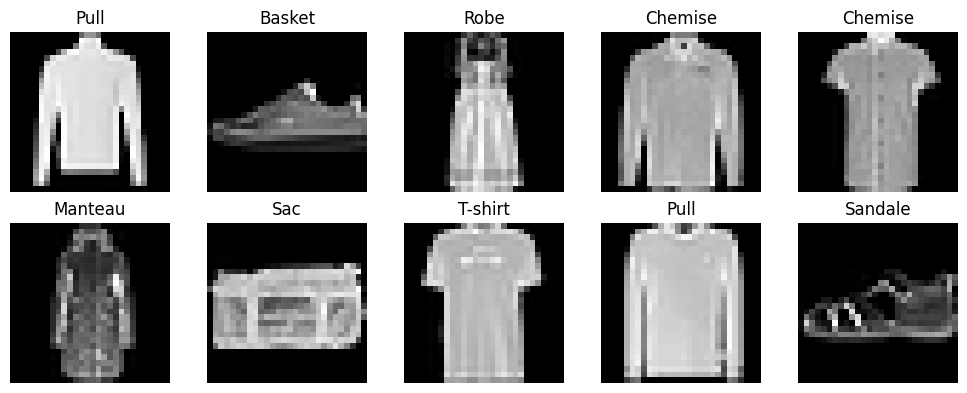

In [54]:

#  Affichage de quelques exemples d'images

images, labels = next(iter(train_loader))

plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(images[i].squeeze(), cmap="gray")
    plt.title(class_names[labels[i].item()])
    plt.axis("off")

plt.tight_layout()
plt.show()


Les images sont de faible résolution et contiennent peu de détails. Cela rend le jeu de données adapté pour un premier travail avec des CVAEs, car le modèle n’a pas besoin de capturer des variations complexes. Malgré cela, il y a certaines classes qui présentent des similarités visuelles telles que les `t-shirts`, les `pulls` et les `chemises`, `bottine` et `basket`. Ces couples posent des défis pour la génération conditionnelle.  

### 4 Répartition des classes

Afin de vérifier l’équilibre des classes dans les différents ensembles, nous analysons la distribution des labels dans les jeux d’entraînement, de validation et de test.


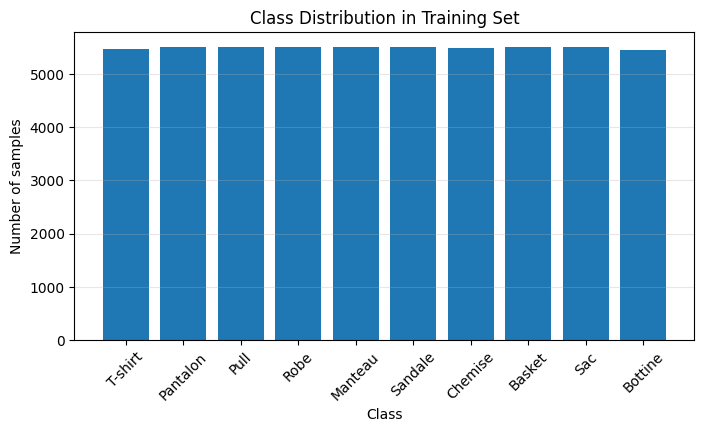

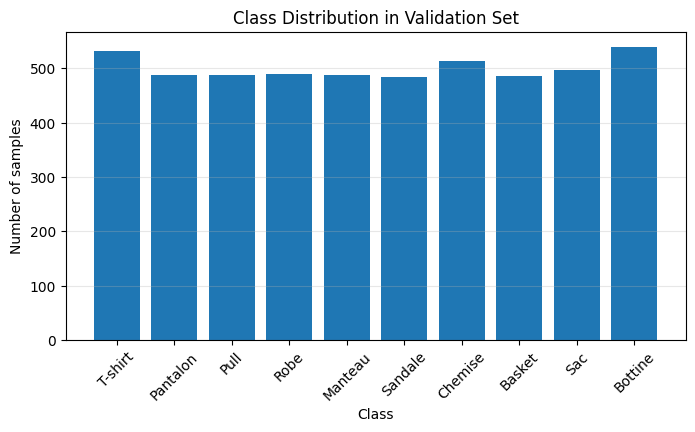

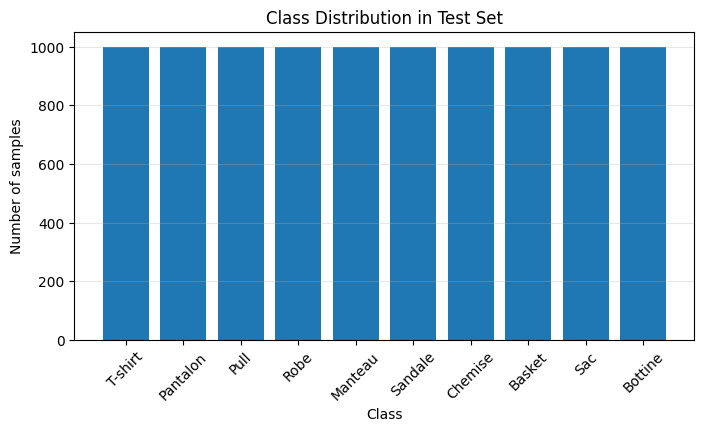

In [5]:

# Training set

train_labels = [label for _, label in train_dataset]
train_counts = np.bincount(train_labels, minlength=len(class_names))

plt.figure(figsize=(8, 4))
plt.bar(range(len(class_names)), train_counts)
plt.xticks(range(len(class_names)), class_names, rotation=45)
plt.xlabel("Class")
plt.ylabel("Number of samples")
plt.title("Class Distribution in Training Set")
plt.grid(axis="y", alpha=0.3)
plt.show()

# Validation set
val_labels = [label for _, label in val_dataset]
val_counts = np.bincount(val_labels, minlength=len(class_names))

plt.figure(figsize=(8, 4))
plt.bar(range(len(class_names)), val_counts)
plt.xticks(range(len(class_names)), class_names, rotation=45)
plt.xlabel("Class")
plt.ylabel("Number of samples")
plt.title("Class Distribution in Validation Set")
plt.grid(axis="y", alpha=0.3)
plt.show()

# Test set

test_labels = [label for _, label in test_dataset]
test_counts = np.bincount(test_labels, minlength=len(class_names))

plt.figure(figsize=(8, 4))
plt.bar(range(len(class_names)), test_counts)
plt.xticks(range(len(class_names)), class_names, rotation=45)
plt.xlabel("Class")
plt.ylabel("Number of samples")
plt.title("Class Distribution in Test Set")
plt.grid(axis="y", alpha=0.3)
plt.show()

Le jeu de données Fashion-MNIST contient des classes très equilibrées, il n'y a pas de classe majoritaire ni minoritaire.


## III. Modèle CVAE

### 1 Architecture du modèle

L’architecture du Conditional Variational Autoencoder (CVAE) utilisée dans ce projet est inspirée du Variational Autoencoder convolutionnel étudié lors des travaux pratiques du cours. Cette architecture est composé de deux blocs principaux : un encodeur et un décodeur .

**Encodeur :**  
L’encodeur se decompose en une tête de CNN et un bloc de multicouche entièrement connecté. Les convolutions permettent d’extraire efficacement des caractéristiques visuelles pertinentes tout en préservant la structure spatiale des données. Le bloc entièrement connecté prend ensuite les maps de caractéristiques extraites par la tête CNN et le label one-hot $y$ pour produire les paramètres de la distribution latente conditionnée $q_\phi(z \mid x, y)$.

**Décodeur :**  
Le décodeur se decompose en une couche linear suivie d'un bloc de CNN, on peut dire que le décodeur est plus ou moins symétrique à celle de l’encodeur. La couche linear prend le vecteur latent $z$ concaténé avec le label one-hot $y$ comme entrée, puis le bloc de CNN utilise la sortie de cette couche pour reconstruire l’image $\hat{x}$.


In [ ]:
class ConvCVAE(nn.Module):
    def __init__(self, latent_dim=10, condition_dim=10):
        super(ConvCVAE, self).__init__()

        # Dimension de l’espace latent z
        self.latent_dim = latent_dim

        # Dimension du vecteur de condition (10 classes pour Fashion-MNIST)
        self.condition_dim = condition_dim

        # ENCODER

        self.encoder = nn.Sequential(
            # Première couche : extraction de motifs locaux (bords, textures simples)
            nn.Conv2d(1, 32, kernel_size=4, stride=2, padding=1),  # -> (32, 14, 14)
            nn.BatchNorm2d(32),  # Stabilise l’apprentissage
            nn.ReLU(),           # Introduit la non-linéarité

            # Deuxième couche : motifs plus abstraits (formes, parties d’objets)
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),  # -> (64, 7, 7)
            nn.BatchNorm2d(64),
            nn.ReLU(),

            # Troisième couche : représentation compacte et riche
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),  # -> (128, 4, 4)
            nn.BatchNorm2d(128),
            nn.ReLU(),
        )

        # Latent space (Fully Connected layers)

        # Après l’encodeur, la représentation est aplatie puis concaténée
        # avec le vecteur de condition c (one-hot).
        # Cela permet d’apprendre la distribution q(z | x, c).
        self.fc_mu = nn.Linear(128 * 4 * 4 + condition_dim, latent_dim)
        self.fc_logvar = nn.Linear(128 * 4 * 4 + condition_dim, latent_dim)


        # DECODER

        # Cette couche projette le vecteur latent z (conditionné par c)
        # vers une représentation compatible avec le décodeur
        self.fc_decode = nn.Linear(latent_dim + condition_dim, 128 * 4 * 4)



        # Le décodeur utilise des convolutions transposées afin de reconstruire
        # progressivement l’image en restaurant sa structure spatiale.
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1),  # -> (64, 8, 8)
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),   # -> (32, 16, 16)
            nn.BatchNorm2d(32),
            nn.ReLU(),

            # Dernière couche : reconstruction de l’image en niveaux de gris
            nn.ConvTranspose2d(32, 1, kernel_size=4, stride=2, padding=1),    # -> (1, 28, 28)
            nn.Sigmoid()
        )

    # Encoder forward pass

    def encode(self, x, y):
        """
        Encode l’image x conditionnée par la classe c.
        Implémente q(z | x, c).
        """
        x = self.encoder(x)
        x = x.view(-1, 128 * 4 * 4)
        c = c = F.one_hot(y, num_classes=self.condition_dim).float()
        x = torch.cat([x, c], dim=1)

        # Estimation des paramètres de la distribution latente
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)

        return mu, logvar

    # Reparameterization trick

    def sample(self, mu, logvar):
        """
        Échantillonnage de z à partir de  N(mu, sigma^2) en utilisant le reparameterization trick
        """
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    # Decoder forward pass

    def decode(self, z, y):
        """
        Reconstruit l’image à partir du vecteur latent z conditionné par la classe c.
         Implémente p(x | z, c).
        """

        c = F.one_hot(y, num_classes=self.condition_dim).float().to(z.device)
        z = torch.cat([z, c], dim=1)
        x = self.fc_decode(z)
        x = x.view(-1, 128, 4, 4)

        # Reconstruction progressive de l’image
        x = self.decoder(x)
        return x

    # Forward pass

    def forward(self, x, y):
        """
        x -> encode -> sample -> decode
        """
        mu, logvar = self.encode(x, y)
        z = self.sample(mu, logvar)
        return self.decode(z, y), mu, logvar
    

    def generate_samples_by_class(self, class_batch, device='cpu'):
        self.eval()

        with torch.no_grad():
            # Latent vectors
            z = torch.randn(len(class_batch), self.latent_dim).to(class_batch.device)

            # Class labels from input
            labels = class_batch

            # Decode
            samples = self.decode(z, labels)

        return samples



### 2 Entraînement du CVAE


####  2.1 Fonction de perte du CVAE

L’apprentissage du Conditional Variational Autoencoder repose sur la minimisation d’une
fonction de perte composée de deux termes : une perte de reconstruction et un terme de
régularisation basé sur la divergence de Kullback–Leibler.

La fonction de perte du CVAE s’écrit
$$
\mathcal{L}_{\text{CVAE}} =
\mathcal{L}_{\text{recon}} + \beta\mathcal{L}_{\text{KL}}.
$$

Le terme de reconstruction mesure la similarité entre l’image d’entrée $x$ et l’image
reconstruite $\hat{x}$. Étant donné que les images sont normalisées dans l’intervalle
$[0,1]$, nous utilisons la Binary Cross-Entropy
$$
\mathcal{L}_{\text{recon}} =
-\sum \big[ x \log(\hat{x}) + (1 - x)\log(1 - \hat{x}) \big].
$$

Le terme de régularisation correspond à la divergence de Kullback–Leibler entre la
distribution latente apprise $q_\phi(z \mid x, y)$ et la loi normale standard
$\mathcal{N}(0, I)$
$$
\mathcal{L}_{\text{KL}} =
-\frac{1}{2} \sum \left(1 + \log \sigma(x)^2 - \mu(x)^2 - \sigma(x)^2 \right).
$$

Ce terme contraint l’espace latent à rester proche d’une distribution gaussienne, ce qui
facilite la génération d’images cohérentes lors de l’échantillonnage.


In [7]:
# Implement the loss function
def loss_function_cvae(recon_x, x, mu, logvar, beta=1):
    BCE = F.binary_cross_entropy(recon_x, x, reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + beta * KLD, BCE, KLD


#### 2.2 Metric d'évaluation
Pour évaluer la qualité des images générées par le CVAE, et aussi de choisir un bon hyperparamètre $\beta$ et la dimension de l'espace latent $d_z$, nous utilisons la métrique **Fréchet Inception Distance** (FID). La FID mesure la distance entre les distributions des caractéristiques extraites des images réelles et des images générées par le modèle. L'idée principale de FID est de comparer les statistiques (moyenne et covariance) des map de caractéristiques extraites par un CNN. Ce CNN est généralement un modèle pré-entraîné sur un grand ensemble de données (ImageNet), cependant, dans notre cas, un CNN entrainé sur ImageNet ne convient pas car les images de Fashion-MNIST sont en niveaux de gris et de faible résolution (28x28 pixels). Par conséquent, nous avons choisi d'entrainer un simple CNN sur Fashion-MNIST pour le taĉhe de classification, puis nous utilisons ce modèle pour extraire les caractéristiques des images réelles et générées afin de calculer la FID metric. Une fois les caractéristiques extraites, la FID est calculée en utilisant la formule suivante :
$$
\text{FID} = \|\mu_r - \mu_g\|^2 + \text{Tr}\left(\Sigma_r + \Sigma_g - 2(\Sigma_r \Sigma_g)^{1/2}\right),
$$
où $(\mu_r, \Sigma_r)$ et $(\mu_g, \Sigma_g)$ sont respectivement la moyenne et la covariance des caractéristiques extraites des images réelles et générées.


On difinit tout d'abord la classifieur CNN pour extraire les caractéristiques des images réelles et générées.

In [55]:
class Classifier_FID(nn.Module):
    """Simple CNN for Fashion MNIST classification"""
    
    def __init__(self, num_classes=10, dropout=0.5):
        super(Classifier_FID, self).__init__()
        
        # Convolutional layers
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        
        self.pool = nn.MaxPool2d(2, 2)
        
        self.fc1 = nn.Linear(128 * 3 * 3, 256)
        self.dropout1 = nn.Dropout(dropout)
        
        self.fc2 = nn.Linear(256, 128)
        self.dropout2 = nn.Dropout(dropout)
        
        self.fc3 = nn.Linear(128, num_classes)

    def forward_CNN(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.pool(x)  
        
        x = self.conv2(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.pool(x)  
        
        x = self.conv3(x)
        x = self.bn3(x)
        x = F.relu(x)
        x = self.pool(x)  
        return x
    
    def forward_FC(self, x):
        x = x.view(x.size(0), -1)
        
        x = self.fc1(x)
        x = F.relu(x)
        x = self.dropout1(x)
        
        x = self.fc2(x)
        x = F.relu(x)
        x = self.dropout2(x)
        
        x = self.fc3(x)
        
        return x
    
    def forward(self, x):
        return self.forward_FC(self.forward_CNN(x))


In [15]:
# Configuration du matériel
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_classifier = Classifier_FID().to(device)

# Hyperparamètres
optimizer = optim.Adam(model_classifier.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()
epochs = 20

print(f"Début de l'entraînement du classifier sur {device}...")

for epoch in range(epochs):
    model_classifier.train()
    train_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model_classifier(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

   ###  Accuracy pour chaque epoch
    model_classifier.eval()
    correct = 0
    total = 0
    n_max = 500
    n_current = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            n_current += inputs.size(0)
            if n_current > n_max:
                break
            outputs = model_classifier(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f"Époque [{epoch+1}/{epochs}] - Loss: {train_loss/len(train_loader):.4f} - Accuracy Test: {accuracy:.2f}%")

# Sauvegarde du classifier
torch.save(model_classifier.state_dict(), "fmnist_classifier.pth")
print("Classifier entraîné et sauvegardé sous 'fmnist_classifier.pth'.")

Début de l'entraînement du classifier sur cuda...
Époque [1/20] - Loss: 0.5529 - Accuracy Test: 90.18%
Époque [2/20] - Loss: 0.3359 - Accuracy Test: 91.74%
Époque [3/20] - Loss: 0.2870 - Accuracy Test: 92.19%
Époque [4/20] - Loss: 0.2552 - Accuracy Test: 93.30%
Époque [5/20] - Loss: 0.2283 - Accuracy Test: 90.85%
Époque [6/20] - Loss: 0.2081 - Accuracy Test: 93.08%
Époque [7/20] - Loss: 0.1934 - Accuracy Test: 91.96%
Époque [8/20] - Loss: 0.1727 - Accuracy Test: 93.30%
Époque [9/20] - Loss: 0.1624 - Accuracy Test: 93.08%
Époque [10/20] - Loss: 0.1466 - Accuracy Test: 92.19%
Époque [11/20] - Loss: 0.1404 - Accuracy Test: 92.63%
Époque [12/20] - Loss: 0.1257 - Accuracy Test: 93.30%
Époque [13/20] - Loss: 0.1195 - Accuracy Test: 92.19%
Époque [14/20] - Loss: 0.1110 - Accuracy Test: 93.08%
Époque [15/20] - Loss: 0.1059 - Accuracy Test: 93.08%
Époque [16/20] - Loss: 0.0993 - Accuracy Test: 91.29%
Époque [17/20] - Loss: 0.0886 - Accuracy Test: 92.86%
Époque [18/20] - Loss: 0.0857 - Accuracy 

On definit la FID entre deux ensembles d'images réelles et générées comme suit:

In [16]:
# define function to compute FID
def calculate_fid(mu1, sigma1, mu2, sigma2):
    """Calculate the Fréchet Inception Distance (FID) between two distributions."""
    diff = mu1 - mu2
    covmean, _ = sqrtm(sigma1 @ sigma2, disp=False)
    
    # Numerical stability
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    
    fid = diff.dot(diff) + np.trace(sigma1 + sigma2 - 2 * covmean)
    return fid

# define end to end function to calculate FID between real and generated images
@torch.no_grad()
def fid_between_real_and_generated(model_classifier, model_cvea, real_loader, n=1000, device="cpu", reduction='mean'):
    """Calculate FID between real images from real_loader and generated_images using model."""
    model_cvea.eval()
    model_classifier.eval()
    
    # Extract features for real images
    real_features = []
    generated_features = []
    n_sampled = 0
    for inputs, labels in real_loader:
        inputs = inputs.to(device)
        features =  model_classifier.forward_CNN(inputs)
        features = features.view(features.size(0), -1)
        real_features.append(features.cpu().numpy())

        generated_images = model_cvea.generate_samples_by_class(labels.to(device))
        features_prime =  model_classifier.forward_CNN(generated_images)
        features_prime = features_prime.view(features_prime.size(0), -1)
        generated_features.append(features_prime.cpu().numpy())
        n_sampled += len(labels)
        if n_sampled >= n:
            break
    real_features = np.concatenate(real_features, axis=0)
    generated_features = np.concatenate(generated_features, axis=0)

    # Compute statistics
    mu_real = np.mean(real_features, axis=0)
    sigma_real = np.cov(real_features, rowvar=False)
    mu_gen = np.mean(generated_features, axis=0)
    sigma_gen = np.cov(generated_features, rowvar=False)
    # Compute FID
    fid = calculate_fid(mu_real, sigma_real, mu_gen, sigma_gen)
    return fid




On a maintenant une bonne metrique pour evaluer la qualité des images générées par notre CVAE, et aussi pour choisir un bon hyperparamètre $\beta$ et la dimension de l'espace latent $d_z$. Commencons à entrainer le notre CVAE avec different couples de hyperparametres.

#### 2.2 Sélection des hyperparamètres par grid search

Nous avons effectué une recherche par grille (*grid search*) afin d’étudier  l’influence de plusieurs hyperparamètres du CVAE sur ses performances.

Les hyperparamètres considérés sont :
- la dimension de l’espace latent ($d_z$),
- le poids du terme de régularisation KL ($\beta$).

Le taux d’apprentissage et le nombre d’époques sont fixés afin de garantir une comparaison équitable entre les différentes configurations.

Pour chaque combinaison d’hyperparamètres, le modèle est entraîné pendant un nombre fixe d’époques. À chaque époque :
- la fonction de perte est minimisée sur l’ensemble d’entraînement (mise à jour des poids),
- puis évaluée sur l’ensemble de validation, sans mise à jour des paramètres.

La fonction de perte utilisée est :
$$
\mathcal{L} = \mathcal{L}_{\text{BCE}} + \beta \, \mathcal{L}_{\text{KL}},
$$
où $\mathcal{L}_{\text{BCE}}$ mesure l’erreur de reconstruction et $\mathcal{L}_{\text{KL}}$ régularise l’espace latent.

Le meilleur modèle est sélectionné comme celui présentant la plus faible perte de validation finale, ce critère permettant d’identifier la configuration offrant le meilleur compromis entre qualité de reconstruction et capacité de généralisation, sans utiliser le jeu de test.

In [11]:

SAVE_PATH = "best_cvae_model.pth"


In [17]:

# Grid search parameters

latent_dims = [8, 16, 32]
betas = [0.25, 0.5, 1.0, 2.0]
learning_rate = 1e-3
epochs = 5

best_config = None
lowest_val_loss = float("inf")
best_losses = None  # pour stocker les courbes du meilleur modèle

# Grid search loop
FID_list = []

for latent_dim, beta in itertools.product(latent_dims, betas):

    print(f"\nTraining CVAE | latent_dim={latent_dim}, beta={beta}")

    model = ConvCVAE(latent_dim=latent_dim, condition_dim= 10).to(device)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)


    for epoch in range(1, epochs + 1):
        # TRAIN
        model.train()
        epoch_total, epoch_recon, epoch_kl = 0.0, 0.0, 0.0

        for x, y in train_loader:
            x = x.to(device)
            y = y.to(device)

            optimizer.zero_grad()
            recon_x, mu, logvar = model(x, y)
            loss, bce, kld = loss_function_cvae(recon_x, x, mu, logvar, beta)

            loss.backward()
            optimizer.step()

            epoch_total += loss.item()
            epoch_recon += bce.item()
            epoch_kl += kld.item()

        n_train = len(train_loader.dataset)
        train_total = epoch_total / n_train
        train_recon = epoch_recon / n_train
        train_kl = epoch_kl / n_train


    #  VALIDATION with FID calculation, not loss 
    model.eval()
    fid_value = 0.0
    fid_value = fid_between_real_and_generated(model_classifier=model_classifier,
                                             model_cvea=model,
                                             real_loader=val_loader,
                                             n=1000,
                                             device=device)
    FID_list.append(fid_value)
    print(f"latent_dim={latent_dim}, beta={beta} | FID: {fid_value:.4f}")            
        
        






Training CVAE | latent_dim=8, beta=0.25
latent_dim=8, beta=0.25 | FID: 32.8459

Training CVAE | latent_dim=8, beta=0.5
latent_dim=8, beta=0.5 | FID: 31.8574

Training CVAE | latent_dim=8, beta=1.0
latent_dim=8, beta=1.0 | FID: 30.1233

Training CVAE | latent_dim=8, beta=2.0
latent_dim=8, beta=2.0 | FID: 32.4602

Training CVAE | latent_dim=16, beta=0.25
latent_dim=16, beta=0.25 | FID: 31.4605

Training CVAE | latent_dim=16, beta=0.5
latent_dim=16, beta=0.5 | FID: 30.1897

Training CVAE | latent_dim=16, beta=1.0
latent_dim=16, beta=1.0 | FID: 29.4031

Training CVAE | latent_dim=16, beta=2.0
latent_dim=16, beta=2.0 | FID: 32.3843

Training CVAE | latent_dim=32, beta=0.25
latent_dim=32, beta=0.25 | FID: 28.9627

Training CVAE | latent_dim=32, beta=0.5
latent_dim=32, beta=0.5 | FID: 29.0039

Training CVAE | latent_dim=32, beta=1.0
latent_dim=32, beta=1.0 | FID: 30.6950

Training CVAE | latent_dim=32, beta=2.0
latent_dim=32, beta=2.0 | FID: 33.1788


In [18]:
# best FID and corresponding hyperparameters
best_fid = min(FID_list)
best_index = FID_list.index(best_fid)
best_latent_dim = latent_dims[best_index // len(betas)]
best_beta = betas[best_index % len(betas)]
print(f"\nBest FID: {best_fid:.4f} with latent_dim={best_latent_dim}, beta={best_beta}")


Best FID: 28.9627 with latent_dim=32, beta=0.25


On a trouvé que le meilleur couple d'hyperparamètres est $(d_z, \beta) = (32, \, 0.25)$, qui donne la plus petite valeur de FID sur le jeu de test. On remarque que le paramètre $d_z$ est toujours choisi comme la plus valeur possible dans notre grid search. Cette observation peut s'expliquer par le fait qu'un espace latent de plus grande dimension offre une plus grande capacité de représentation, permettant un meilleur reconstruction/génération des images. 

#### 2.3 Entraînement du modèle avec les hyperparamètres optimisés

À l’issue de la recherche d’hyperparamètres, le modèle est entraîné en utilisant la configuration offrant les meilleures performances sur l’ensemble de validation. Cette configuration correspond au meilleur compromis entre la qualité de reconstruction et la régularisation de l’espace latent.

Une fois les hyperparamètres sélectionnés, le modèle CVAE correspondant est réentraîné sur un plus grand nombre d’époques afin d’assurer une convergence satisfaisante. Cette phase d’entraînement final permet au modèle d’exploiter pleinement sa capacité de représentation et d’obtenir un apprentissage stable avant l’analyse des résultats de génération.


In [20]:

# Load best configuration

latent_dim = best_latent_dim
beta = best_beta
learning_rate = 1e-3

# Rebuild model

model = ConvCVAE(
    latent_dim=latent_dim,
    condition_dim=10
).to(device)

optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Final training

final_epochs = 50

total_losses = []
recon_losses = []
kl_losses = []
val_losses = []

for epoch in range(1, final_epochs + 1):

    #  TRAIN
    model.train()
    epoch_total, epoch_recon, epoch_kl = 0.0, 0.0, 0.0

    for x, y in train_loader:
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()
        recon_x, mu, logvar = model(x, y)
        loss, bce, kld = loss_function_cvae(recon_x, x, mu, logvar, beta)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        epoch_total += loss.item()
        epoch_recon += bce.item()
        epoch_kl += kld.item()
    n_train = len(train_loader.dataset)
    total_losses.append(epoch_total / n_train)
    recon_losses.append(epoch_recon / n_train)
    kl_losses.append(epoch_kl / n_train)

    #  VALIDATION
    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for x, y in val_loader:
            x = x.to(device)
            y = y.to(device)

            recon_x, mu, logvar = model(x, y)
            loss, _, _ = loss_function_cvae(recon_x, x, mu, logvar, beta)
            val_loss += loss.item()

    val_loss /= len(val_loader.dataset)
    val_losses.append(val_loss)

    print(
        f"Epoch {epoch}/{final_epochs} | "
        f"Train total={total_losses[-1]:.4f} | "
        f"Recon={recon_losses[-1]:.4f} | "
        f"KL={kl_losses[-1]:.4f} | "
        f"Val={val_losses[-1]:.4f}"
    )
FINAL_PATH = "final_cvae.pth"
torch.save(model.state_dict(), FINAL_PATH)
print("Final CVAE model saved successfully")


Epoch 1/50 | Train total=244.8091 | Recon=235.0885 | KL=38.8825 | Val=231.5297
Epoch 2/50 | Train total=227.0581 | Recon=217.3165 | KL=38.9664 | Val=227.4280
Epoch 3/50 | Train total=224.6661 | Recon=215.0333 | KL=38.5313 | Val=225.4377
Epoch 4/50 | Train total=223.3590 | Recon=213.8145 | KL=38.1782 | Val=224.6040
Epoch 5/50 | Train total=222.4314 | Recon=212.9759 | KL=37.8219 | Val=223.0694
Epoch 6/50 | Train total=221.8003 | Recon=212.4040 | KL=37.5853 | Val=222.6248
Epoch 7/50 | Train total=221.2839 | Recon=211.9470 | KL=37.3478 | Val=222.5029
Epoch 8/50 | Train total=220.8616 | Recon=211.5876 | KL=37.0958 | Val=222.0420
Epoch 9/50 | Train total=220.5334 | Recon=211.2959 | KL=36.9500 | Val=221.8532
Epoch 10/50 | Train total=220.2939 | Recon=211.0810 | KL=36.8515 | Val=221.7966
Epoch 11/50 | Train total=220.0350 | Recon=210.8442 | KL=36.7632 | Val=221.3001
Epoch 12/50 | Train total=219.8004 | Recon=210.6589 | KL=36.5657 | Val=220.9209
Epoch 13/50 | Train total=219.5940 | Recon=210.46

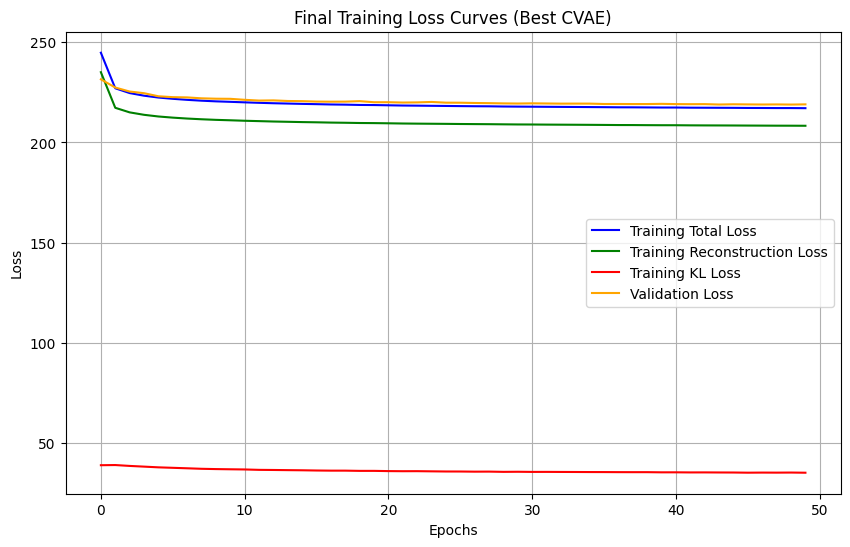

In [21]:
plt.figure(figsize=(10, 6))
plt.plot(total_losses, label="Training Total Loss", color="b")
plt.plot(recon_losses, label="Training Reconstruction Loss", color="g")
plt.plot(kl_losses, label="Training KL Loss", color="r")
plt.plot(val_losses, label="Validation Loss", color="orange")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Final Training Loss Curves (Best CVAE)")
plt.legend()
plt.grid(True)
plt.show()


Les courbes d’apprentissage montrent que le modèle CVAE converge de manière stable après environ 50 epochs. Les pertes d’entraînement et de validation diminuent simultanément et restent très proches l’une de l’autre, ce qui indique l’absence de surapprentissage et une bonne capacité de généralisation du modèle. 

Par ailleurs, la divergence de Kullback–Leibler demeure stable et strictement positive, ce qui montre que la variable latente \(z\) conserve des informations pertinentes sur les données d’entrée et qu’elle est effectivement exploitée par le décodeur. Cela signifie que le modèle ne présente pas de phénomène de *posterior collapse*, c’est-à-dire que l’espace latent ne s’effondre pas vers la distribution a priori $\mathcal{N}(0,I) $ et n’est pas ignoré par le décodeur. L’espace latent est ainsi bien structuré et permet la génération de données variées.

Ces observations confirment que le modèle a atteint un état de convergence stable à l’issue de l’entraînement final.


In [22]:
# Load final trained model
cvae = ConvCVAE(
    latent_dim=latent_dim,
    condition_dim=10
).to(device)

cvae.load_state_dict(torch.load(FINAL_PATH))
cvae.eval()

print("Final CVAE model loaded successfully")


Final CVAE model loaded successfully


## III Résultats

On implemente une fonction pour visualiser et comparer les images originales avec leurs reconstructions produites par le modèle CVAE.


In [23]:

def image_comparison(original_images, reconstructions, n_images=6):
    """Plots the original images and its reconstructions for comparison

    Args:
        original_image (torch.Tensor): The original images
        reconstructions (torch.Tensor): Reconstruction of the original images
    """
    fig, ax = plt.subplots(2, n_images, figsize=(10, 5))

    for i in range(n_images):
        # Plot original images
        ax[0, i].imshow(original_images[i], cmap='gray')
        ax[0, i].axis('off')
        ax[0, 0].set_title('Original')

        # Reconstructed images
        ax[1, i].imshow(reconstructions[i], cmap='gray')
        ax[1, i].axis('off')
        ax[1, 0].set_title('Recomstruction')

    plt.tight_layout()
    plt.show()


Nous appliquons ensuite le modèle entraîné à un batch d’images du jeu de test afin de visualiser les reconstructions obtenues.


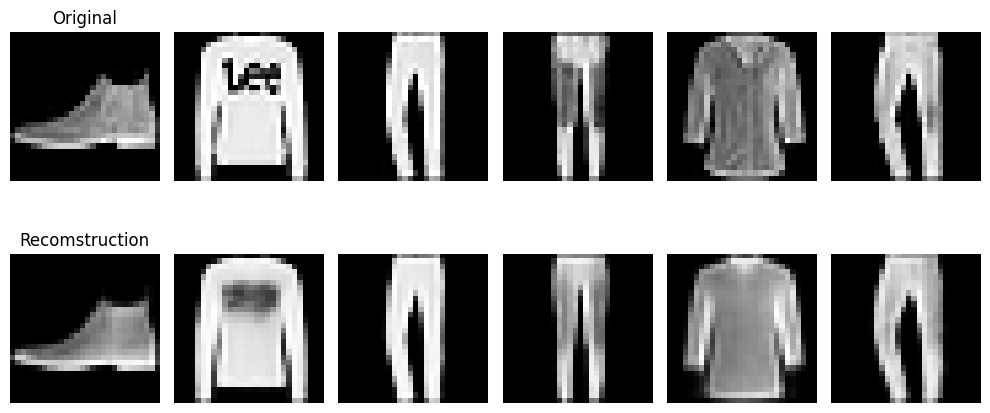

In [24]:
# Récupération d'un batch du jeu de test
images, labels = next(iter(test_loader))

images = images.to(device)
labels = labels.to(device)



# Reconstruction
with torch.no_grad():
    reconstructions, _, _ = cvae(images, labels)

# Conversion pour affichage
images_np = images.cpu().numpy().squeeze()
recons_np = reconstructions.cpu().numpy().squeeze()

# Affichage
image_comparison(images_np, recons_np)


### 1 Visualisation des images generées

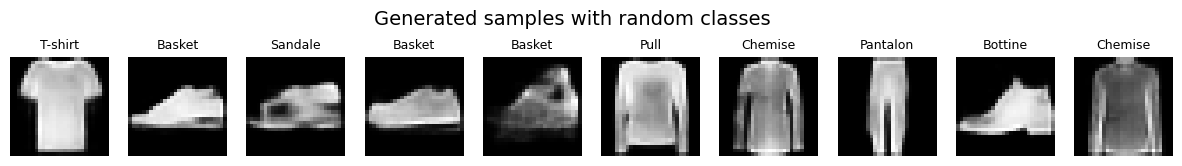

In [26]:
def generate_samples(num_samples=10):
    model.eval()

    with torch.no_grad():
        # Latent vectors
        z = torch.randn(num_samples, model.latent_dim).to(device)

        # Random class labels (integers)
        labels = torch.randint(0, 10, (num_samples,), dtype=torch.long).to(device)

        # Decode
        samples = model.decode(z, labels)

    # Display
    fig, ax = plt.subplots(1, num_samples, figsize=(15, 2))

    for i in range(num_samples):
        ax[i].imshow(samples[i].cpu().squeeze(), cmap="gray")
        ax[i].set_title(class_names[labels[i].item()], fontsize=9)
        ax[i].axis("off")

    plt.suptitle("Generated samples with random classes", fontsize=14)
    plt.show()
    
generate_samples()

### 2. Generation d'images par classes

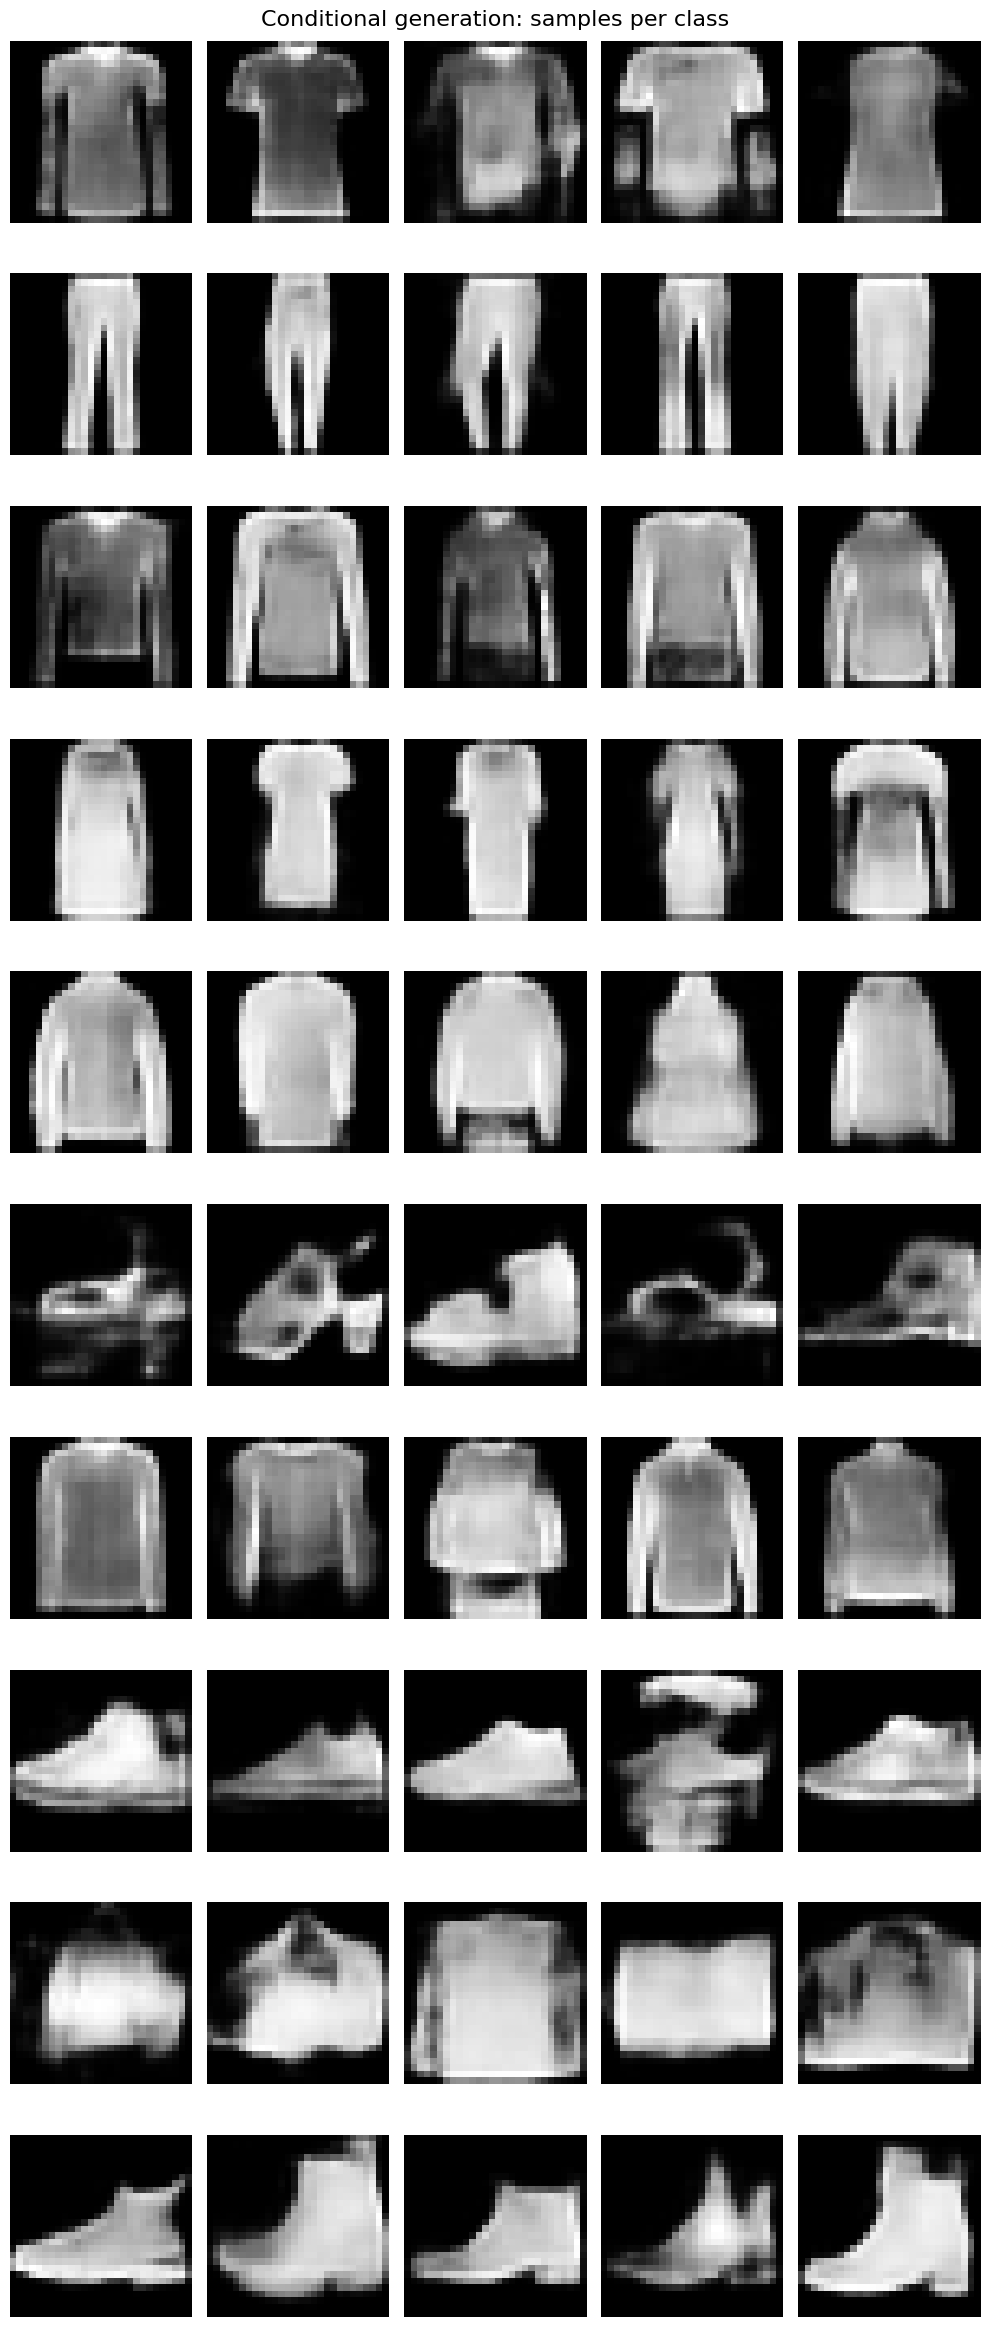

In [30]:
def generate_samples_per_class(num_samples_per_class=5):
    model.eval()

    with torch.no_grad():
        fig, ax = plt.subplots(
            10, num_samples_per_class,
            figsize=(2 * num_samples_per_class, 20 +4 )
        )

        for class_idx in range(10):
            # Latent vectors
            z = torch.randn(num_samples_per_class, model.latent_dim).to(device)

            # Labels entiers (pas one-hot)
            labels = torch.full(
                (num_samples_per_class,),
                class_idx,
                dtype=torch.long
            ).to(device)

            # Génération
            samples = model.decode(z, labels)

            for i in range(num_samples_per_class):
                ax[class_idx, i].imshow(
                    samples[i].cpu().squeeze(), cmap="gray"
                )
                ax[class_idx, i].axis("off")

                # Titre seulement sur la première image de chaque ligne
                if i == 0:
                    ax[class_idx, i].set_ylabel(
                        class_names[class_idx],
                        fontsize=12,
                        rotation=0,
                        labelpad=40
                    )

        plt.suptitle(
            "Conditional generation: samples per class",
            fontsize=16
        )
        plt.tight_layout()
        plt.show()

generate_samples_per_class(num_samples_per_class=5)


Commentaires:
- Les sacs et les sandales sont peu recognisables.
- Les robes sont parfois confondues avec des t-shirts/pull/Chemises.

### 3 Visualisation de l’espace latent

Afin d’analyser l’influence du poids du terme de divergence de Kullback–Leibler, plusieurs modèles CVAE ont été entraînés avec une dimension latente fixée à 2 et différentes valeurs de β. Ce choix permet une visualisation directe de l’espace latent et facilite l’interprétation de l’effet de la régularisation sur la structure des représentations apprises.


In [34]:
latent_dim = 2
condition_dim = 10
kl_weights = [ 0.5,1.0, 100]
num_epochs = 20
learning_rate = 1e-3


In [35]:
def plot_latent_space_cvae(model, test_loader, beta):
    model.eval()
    with torch.no_grad():
        all_mu = []
        all_labels = []

        for x, y in test_loader:
            x = x.to(device)
            y = y.to(device)

            mu, _ = model.encode(x, y)
            all_mu.append(mu.cpu())
            all_labels.append(y.cpu())

        z = torch.cat(all_mu).numpy()
        labels = torch.cat(all_labels).numpy()

        plt.figure(figsize=(7, 6))
        scatter = plt.scatter(
            z[:, 0], z[:, 1],
            c=labels,
            cmap="tab10",
            alpha=0.6
        )
        plt.colorbar(scatter, ticks=range(10))
        plt.title(f"Espace latent du CVAE (β = {beta})")
        plt.xlabel("$z_1$")
        plt.ylabel("$z_2$")
        plt.grid(True)
        plt.show()



Training CVAE with beta = 0.5
Epoch 1/20 | Loss = 265.5796
Epoch 2/20 | Loss = 254.3312
Epoch 3/20 | Loss = 252.9947
Epoch 4/20 | Loss = 251.9815
Epoch 5/20 | Loss = 251.3549
Epoch 6/20 | Loss = 250.9306
Epoch 7/20 | Loss = 250.4575
Epoch 8/20 | Loss = 250.2200
Epoch 9/20 | Loss = 249.8747
Epoch 10/20 | Loss = 249.6214
Epoch 11/20 | Loss = 249.3780
Epoch 12/20 | Loss = 249.1869
Epoch 13/20 | Loss = 249.0076
Epoch 14/20 | Loss = 248.7174
Epoch 15/20 | Loss = 248.5867
Epoch 16/20 | Loss = 248.4483
Epoch 17/20 | Loss = 248.2932
Epoch 18/20 | Loss = 248.1298
Epoch 19/20 | Loss = 247.9987
Epoch 20/20 | Loss = 247.8306


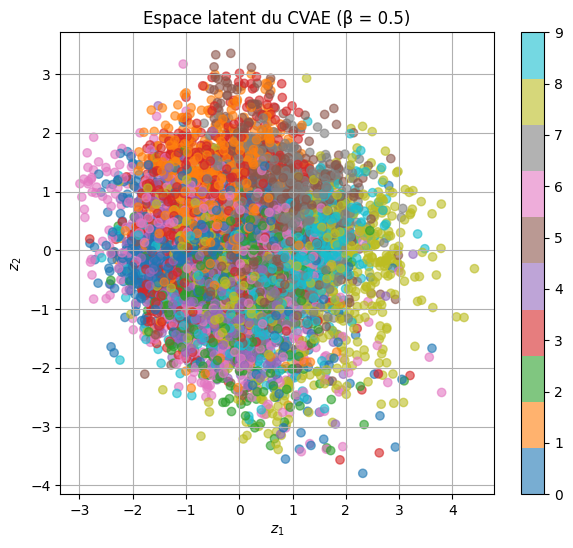


Training CVAE with beta = 1.0
Epoch 1/20 | Loss = 269.2084
Epoch 2/20 | Loss = 257.6469
Epoch 3/20 | Loss = 255.8778
Epoch 4/20 | Loss = 254.8743
Epoch 5/20 | Loss = 254.2944
Epoch 6/20 | Loss = 253.7332
Epoch 7/20 | Loss = 253.4282
Epoch 8/20 | Loss = 253.0010
Epoch 9/20 | Loss = 252.7368
Epoch 10/20 | Loss = 252.3820
Epoch 11/20 | Loss = 252.2227
Epoch 12/20 | Loss = 251.9081
Epoch 13/20 | Loss = 251.7793
Epoch 14/20 | Loss = 251.4879
Epoch 15/20 | Loss = 251.4507
Epoch 16/20 | Loss = 251.2008
Epoch 17/20 | Loss = 251.1064
Epoch 18/20 | Loss = 250.9225
Epoch 19/20 | Loss = 250.7504
Epoch 20/20 | Loss = 250.6526


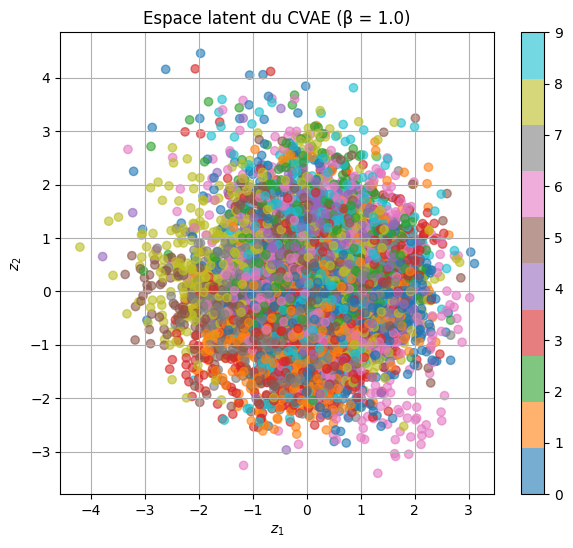


Training CVAE with beta = 100
Epoch 1/20 | Loss = 314.5532
Epoch 2/20 | Loss = 307.9712
Epoch 3/20 | Loss = 307.7886
Epoch 4/20 | Loss = 307.6107
Epoch 5/20 | Loss = 307.4995
Epoch 6/20 | Loss = 307.4572
Epoch 7/20 | Loss = 307.3805
Epoch 8/20 | Loss = 307.3790
Epoch 9/20 | Loss = 307.3077
Epoch 10/20 | Loss = 307.3409
Epoch 11/20 | Loss = 307.2735
Epoch 12/20 | Loss = 307.2428
Epoch 13/20 | Loss = 307.2241
Epoch 14/20 | Loss = 307.2314
Epoch 15/20 | Loss = 307.1832
Epoch 16/20 | Loss = 307.1818
Epoch 17/20 | Loss = 307.1329
Epoch 18/20 | Loss = 307.1484
Epoch 19/20 | Loss = 307.1338
Epoch 20/20 | Loss = 307.1430


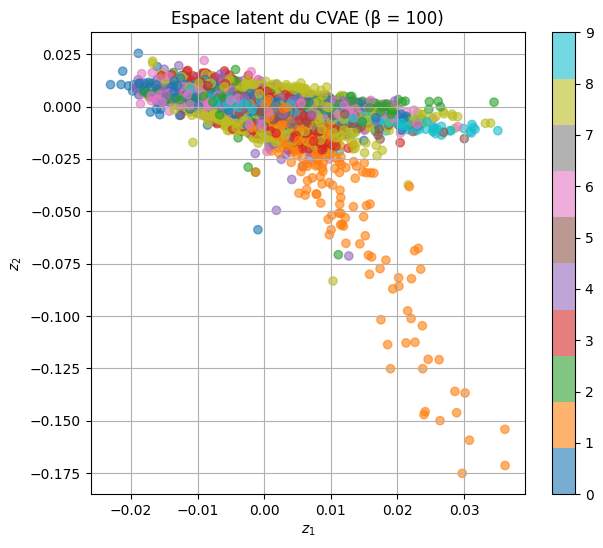

In [36]:
for beta in kl_weights:
    print(f"\nTraining CVAE with beta = {beta}")

    model = ConvCVAE(latent_dim=latent_dim, condition_dim=10).to(device)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0.0

        for x, y in train_loader:
            x = x.to(device)
            y = y.to(device)

            optimizer.zero_grad()
            recon_x, mu, logvar = model(x, y)
            loss, _, _ = loss_function_cvae(recon_x, x, mu, logvar, beta)

            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        print(
            f"Epoch {epoch+1}/{num_epochs} | "
            f"Loss = {epoch_loss / len(train_loader.dataset):.4f}"
        )

    # Visualisation de l'espace latent
    plot_latent_space_cvae(model, test_loader, beta)


L’analyse de l’espace latent met en évidence l’effet du poids $\beta$ associé au terme de divergence KL. Pour des valeurs faibles de $\beta$, l’espace latent est fortement dispersé et peu structuré, indiquant que le modèle utilise largement les variables latentes pour encoder l’information, au détriment de la régularisation. En revanche, pour des valeurs élevées de $\beta$, la contrainte KL domine la fonction de perte, conduisant à une contraction excessive de l’espace latent et à une perte d’information.

## IV. Modèle CVAE-GAN

Cette section est une effort pour aller plus loin dans l'amélioration de la qualité des images générées par le CVAE en intégrant un composant GAN (Generative Adversarial Network), nous nous inspirons de l'article: https://arxiv.org/pdf/1703.10155

![training loss curve](https://drive.google.com/thumbnail?id=1WpxABTfssdEy6LmTHpwdUnsT8SCUmyCL&sz=w1000)

### 1 Choix d’architecture pour $D$ (Discriminateur)

Conformément à l’article CVAE-GAN, le discriminateur $D$ a deux rôles : (i) distinguer **réel/faux**, et (ii) fournir une représentation interne $f_D(x)$ utilisée pour la contrainte de *mean feature matching* (features prises juste avant la dernière couche fully-connected).

Nous utilisons donc un CNN simple de type DCGAN, adapté à Fashion-MNIST ($1\times 28\times 28$), avec une réduction progressive de la résolution par convolutions à stride 2 :$28\rightarrow 14\rightarrow 7\rightarrow 4,$
et une augmentation des canaux $32\rightarrow 64\rightarrow 128$. Le tenseur final $(128,4,4)$ est aplati en un vecteur de dimension $2048$, qui correspond à $f_D(x)$, puis projeté par une couche FC vers un unique logit (réel/faux).  
LeakyReLU est utilisé pour la robustesse des gradients, et la BatchNorm (à partir de la 2e couche) pour stabiliser l’apprentissage.


In [40]:

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 4, 2, 1),   
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(32, 64, 4, 2, 1),  
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 128, 3, 2, 1), 
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
        )
        self.fc = nn.Linear(128 * 4 * 4, 1)

    def forward(self, x, return_features=False):
        h = self.conv(x)
        feat = h.view(x.size(0), -1)         
        logits = self.fc(feat).squeeze(1)     
        if return_features:
            return logits, feat
        return logits


### 2 Choix d’architecture pour $C$ (Classifieur)

Le classifieur $C$ est entraîné à prédire la classe (10 catégories) des images Fashion-MNIST.  
Nous adoptons un backbone convolutionnel proche de celui de $D$ (réduction $28\rightarrow14\rightarrow7\rightarrow4$ et canaux $32\rightarrow64\rightarrow128$), afin d’obtenir une représentation interne stable et suffisamment discriminante.

Comme dans l’article CVAE-GAN, on récupère également un vecteur de caractéristiques intermédiaires $f_C(x)$ (juste avant la couche fully-connected) : le tenseur final $(128,4,4)$ est aplati en un vecteur de dimension $2048$, puis projeté par une couche FC vers $10$ logits (classification multi-classes).  
Ces features $f_C(x)$ sont ensuite utilisées pour imposer une contrainte de cohérence conditionnelle (*conditional feature matching*) lors de l’entraînement du générateur.


In [41]:
class Classifier(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 4, 2, 1),
            nn.ReLU(inplace=True),

            nn.Conv2d(32, 64, 4, 2, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.Conv2d(64, 128, 3, 2, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
        )
        self.fc = nn.Linear(128 * 4 * 4, num_classes)

    def forward(self, x, return_features=False):
        h = self.conv(x)
        feat = h.view(x.size(0), -1)       # (B, 2048)
        logits = self.fc(feat)             # (B, 10)
        if return_features:
            return logits, feat
        return logits


## 5 Fonctions de perte et utilitaires (CVAE-GAN)

Afin d’entraîner le CVAE-GAN de manière stable, nous définissons plusieurs fonctions de perte et d’échantillonnage utilisées dans la boucle d’apprentissage.




In [42]:
bce_logits = nn.BCEWithLogitsLoss()
ce = nn.CrossEntropyLoss()

def loss_function_cvae_mean(recon_x, x, mu, logvar, beta=1.0):
    bce = F.binary_cross_entropy(recon_x, x, reduction='mean')
    kld = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    return bce + beta * kld, bce, kld

def sample_prior(B, latent_dim, num_classes, device):
    z = torch.randn(B, latent_dim, device=device)
    y = torch.randint(0, num_classes, (B,), device=device)
    return z, y

def mean_feature_matching(feat_real, feat_fake):
    return (feat_real.mean(dim=0) - feat_fake.mean(dim=0)).pow(2).mean()

def conditional_feature_matching(feat_real, y_real, feat_fake, y_fake, num_classes=10):
    loss = 0.0
    classes = torch.unique(torch.cat([y_real, y_fake], dim=0))
    for k in classes:
        mr = (y_real == k)
        mf = (y_fake == k)
        if mr.any() and mf.any():
            loss = loss + (feat_real[mr].mean(0) - feat_fake[mf].mean(0)).pow(2).mean()
    return loss / max(len(classes), 1)


### 3 Entraînement du CVAE-GAN


#### 3.1 Initialisation du CVAE pré-entraîné

Avant d’entraîner le modèle CVAE-GAN, nous réutilisons un CVAE déjà entraîné comme point de départ.  
L’objectif est de partir d’un générateur (décodeur) capable de reconstruire correctement les images, puis de  raffiner ce modèle grâce aux contraintes introduites par $D$ et $C$.

Dans notre cas, on fixe :

- `latent_dim = 32` : dimension de l’espace latent $z$ ;
- `beta = 0.25` : pondération du terme KL dans la perte du CVAE ;
- `num_classes = 10` : nombre de classes Fashion-MNIST.

On instancie ensuite le CVAE avec la même architecture que lors de l’entraînement précédent, puis on charge les poids sauvegardés dans le fichier `final_cvae.pth` :

- l’encodeur et le décodeur sont initialisés avec des poids déjà optimisés ;
- cela accélère l’apprentissage du CVAE-GAN et améliore la stabilité au début de l’entraînement.


In [43]:
latent_dim = 32
beta = 0.25
num_classes = 10

cvae = ConvCVAE(latent_dim=latent_dim, condition_dim=num_classes).to(device)

CKPT_PATH = "final_cvae.pth"
cvae.load_state_dict(torch.load(CKPT_PATH, map_location=device))

print("Loaded pretrained CVAE:", CKPT_PATH)


Loaded pretrained CVAE: final_cvae.pth


#### 3.2 Initialisation de $D$ et $C$ et optimiseurs

On initialise ensuite les deux réseaux ajoutés par le CVAE-GAN : le discriminateur $D$ (réel/faux) et le classifieur $C$ (prédiction de classe).  
Trois optimiseurs Adam sont utilisés : `opt_EG` pour le CVAE (encodeur + décodeur), `opt_D` pour $D$ et `opt_C` pour $C$, avec un taux d’apprentissage de $2\times10^{-4}$.  
Les coefficients `lam_fm_D` et `lam_fm_C` pondèrent respectivement les contraintes de *feature matching* issues de $D$ et de $C$.


In [44]:
D = Discriminator().to(device)
C = Classifier(num_classes=num_classes).to(device)

print("Initialized D and C")
lr_EG = 2e-4
lr_D  = 2e-4
lr_C  = 2e-4

opt_EG = torch.optim.Adam(cvae.parameters(), lr=lr_EG)
opt_D  = torch.optim.Adam(D.parameters(),   lr=lr_D)
opt_C  = torch.optim.Adam(C.parameters(),   lr=lr_C)

lam_fm_D = 5.0
lam_fm_C = 2.0

print("Optimizers ready")

Initialized D and C
Optimizers ready


#### 3.3 Warm-up (stabilisation de $D$ et $C$)

Avant l’entraînement complet du CVAE-GAN, nous effectuons une phase de *warm-up* (2 epochs) où le CVAE pré-entraîné est gelé (`requires_grad=False`). Le CVAE sert uniquement à produire des images générées (reconstruction $x_{rec}$ et génération depuis le prior $x_p$), sans mise à jour de ses poids.

Pendant cette phase, on entraîne :
- le discriminateur $D$ à distinguer les images réelles $x$ des images générées ($x_{rec}$ et $x_p$) via une BCE (réel=1, faux=0) ;
- le classifieur $C$ sur les images réelles uniquement via une cross-entropy, afin d’obtenir une représentation de classe fiable.

Cette étape rend $D$ et $C$ non-aléatoires et stabilise les pertes de *feature matching* utilisées ensuite pour affiner le générateur.


In [45]:
warmup_epochs = 2

for p in cvae.parameters():
    p.requires_grad = False

for epoch in range(1, warmup_epochs + 1):
    cvae.eval()  # frozen
    D.train()
    C.train()

    sumD, sumC = 0.0, 0.0

    for x, y in train_loader:
        x = x.to(device)
        y = y.to(device).long()
        B = x.size(0)

        # generate recon + prior
        with torch.no_grad():
            mu, logvar = cvae.encode(x, y)
            z_post = cvae.sample(mu, logvar)
            x_rec = cvae.decode(z_post, y)

            z_p, y_p = sample_prior(B, latent_dim, num_classes, device)
            x_pri = cvae.decode(z_p, y_p)

        # update D
        opt_D.zero_grad()
        logits_real = D(x)
        logits_rec  = D(x_rec)
        logits_pri  = D(x_pri)

        loss_D = (
            bce_logits(logits_real, torch.ones_like(logits_real)) +
            bce_logits(logits_rec,  torch.zeros_like(logits_rec)) +
            bce_logits(logits_pri,  torch.zeros_like(logits_pri))
        )
        loss_D.backward()
        opt_D.step()

        # ---- update C (real only) ----
        opt_C.zero_grad()
        logits_cls = C(x)
        loss_C = ce(logits_cls, y)
        loss_C.backward()
        opt_C.step()

        sumD += loss_D.item()
        sumC += loss_C.item()

    print(f"[Warmup {epoch}/{warmup_epochs}] D={sumD/len(train_loader):.4f} | C={sumC/len(train_loader):.4f}")

print("Warmup done")


[Warmup 1/2] D=0.2481 | C=0.4539
[Warmup 2/2] D=0.0177 | C=0.2903
Warmup done


#### 3.4 Entraînement complet du CVAE-GAN (mise à jour de $D$, $C$ et $(E,G)$)

Après le warm-up, on **dégèle** le CVAE (`requires_grad=True`) afin de pouvoir affiner l’encodeur $E$ et le décodeur (générateur) $G$.  
À chaque mini-batch, on produit deux types d’images générées : la reconstruction $x_{rec}$ (avec $z\sim q_\phi(z\mid x,y)$) et la génération depuis le prior $x_p$ (avec $z\sim\mathcal{N}(0,I)$).

L’entraînement suit ensuite trois mises à jour successives :

1) **Mise à jour de $D$** : BCE réel/faux pour distinguer $x$ (réel) de $x_{rec}$ et $x_p$ (générés). Les images générées sont détachées (`detach()`) afin de ne pas rétropropager dans $G$ pendant l’update de $D$.

2) **Mise à jour de $C$** : cross-entropy sur les images réelles uniquement pour obtenir un classifieur fiable.

3) **Mise à jour de $(E,G)$** : combinaison de la perte CVAE (BCE + $\beta$KL) et des contraintes de *feature matching* :
- *mean feature matching* via $D$ (réalisme),
- *conditional feature matching* via $C$ (cohérence de classe),
pondérées par `lam_fm_D` et `lam_fm_C`.

Enfin, on évalue à chaque epoch la perte CVAE sur l’ensemble de validation (`ValVAE`) afin de suivre l’évolution de la reconstruction.


In [46]:
for p in cvae.parameters():
    p.requires_grad = True

gan_epochs = 5

for epoch in range(1, gan_epochs + 1):
    cvae.train()
    D.train()
    C.train()

    sumEG, sumD, sumC = 0.0, 0.0, 0.0

    for x, y in train_loader:
        x = x.to(device)
        y = y.to(device).long()
        B = x.size(0)


        mu, logvar = cvae.encode(x, y)
        z_post = cvae.sample(mu, logvar)
        x_rec = cvae.decode(z_post, y)

        z_p, y_p = sample_prior(B, latent_dim, num_classes, device)
        x_pri = cvae.decode(z_p, y_p)


        opt_D.zero_grad()
        logits_real = D(x)
        logits_rec  = D(x_rec.detach())
        logits_pri  = D(x_pri.detach())

        loss_D = (
            bce_logits(logits_real, torch.ones_like(logits_real)) +
            bce_logits(logits_rec,  torch.zeros_like(logits_rec)) +
            bce_logits(logits_pri,  torch.zeros_like(logits_pri))
        )
        loss_D.backward()
        opt_D.step()


        opt_C.zero_grad()
        logits_cls = C(x)
        loss_C = ce(logits_cls, y)
        loss_C.backward()
        opt_C.step()


        opt_EG.zero_grad()

        lossVAE, _, _ = loss_function_cvae_mean(x_rec, x, mu, logvar, beta=beta)

        # D feature matching
        _, feat_real_D = D(x, return_features=True)
        _, feat_rec_D  = D(x_rec, return_features=True)
        _, feat_pri_D  = D(x_pri, return_features=True)
        loss_fmD = mean_feature_matching(feat_real_D, feat_rec_D) + \
                   mean_feature_matching(feat_real_D, feat_pri_D)

        # C conditional feature matching
        _, feat_real_C = C(x, return_features=True)
        _, feat_rec_C  = C(x_rec, return_features=True)
        _, feat_pri_C  = C(x_pri, return_features=True)
        loss_fmC = conditional_feature_matching(feat_real_C, y, feat_rec_C, y, num_classes=num_classes) + \
                   conditional_feature_matching(feat_real_C, y, feat_pri_C, y_p, num_classes=num_classes)

        loss_EG = lossVAE + lam_fm_D * loss_fmD + lam_fm_C * loss_fmC
        loss_EG.backward()

        opt_EG.step()

        sumD  += loss_D.item()
        sumC  += loss_C.item()
        sumEG += loss_EG.item()

    cvae.eval()
    val_loss = 0.0
    with torch.no_grad():
        for x, y in val_loader:
            x = x.to(device)
            y = y.to(device).long()
            recon_x, mu, logvar = cvae(x, y)
            l, _, _ = loss_function_cvae_mean(recon_x, x, mu, logvar, beta=beta)
            val_loss += l.item()
    val_loss /= len(val_loader)

    print(
        f"[Epoch {epoch}/{gan_epochs}] "
        f"D={sumD/len(train_loader):.4f} | "
        f"C={sumC/len(train_loader):.4f} | "
        f"EG={sumEG/len(train_loader):.4f} | "
        f"ValVAE={val_loss:.4f}"
    )


[Epoch 1/5] D=0.6332 | C=0.2410 | EG=0.9812 | ValVAE=0.4247
[Epoch 2/5] D=0.5722 | C=0.2077 | EG=0.8795 | ValVAE=0.4185
[Epoch 3/5] D=0.4617 | C=0.1823 | EG=0.8904 | ValVAE=0.4154
[Epoch 4/5] D=0.4183 | C=0.1558 | EG=0.9067 | ValVAE=0.4136
[Epoch 5/5] D=0.3548 | C=0.1370 | EG=0.9267 | ValVAE=0.4108


On a essayé avec un nombre d'epochs plus élevé, mais le modèle commence à sur-apprendre. 

In [48]:
SAVE_PATH = "final_cvae_gan.pth"
torch.save({
    "cvae": cvae.state_dict(),
    "D": D.state_dict(),
    "C": C.state_dict(),
    "latent_dim": latent_dim,
    "beta": beta,
    "lam_fm_D": lam_fm_D,
    "lam_fm_C": lam_fm_C,
}, SAVE_PATH)

print("Saved:", SAVE_PATH)


Saved: final_cvae_gan.pth


## V Comparaison CVAE vs CVAE-GAN


### 1 Comparaison des reconstructions : CVAE vs CVAE-GAN

Afin de comparer quantitativement et visuellement les deux modèles, nous évaluons la **reconstruction** sur un même mini-batch extrait du jeu de test.

a) On récupère un batch $(x,y)$ depuis `test_loader` et on le place sur le bon device.  
b) On charge le **CVAE de base** (poids `final_cvae.pth`) et le **CVAE-GAN** (on ne récupère que la partie `cvae` du fichier `final_cvae_gan.pth`).  
c) On calcule ensuite, sans gradient (`torch.no_grad()`), les reconstructions :
- $x_{rec}^{CVAE} = G(E(x,y),y)$
- $x_{rec}^{GAN} = G_{GAN}(E_{GAN}(x,y),y)$

d) Enfin, on affiche les résultats sur 3 lignes pour une comparaison directe :

Cette visualisation permet d’observer si l’ajout des contraintes via $D$ et $C$ améliore la netteté ou la qualité perceptuelle des reconstructions, tout en conservant la fidélité globale au contenu.


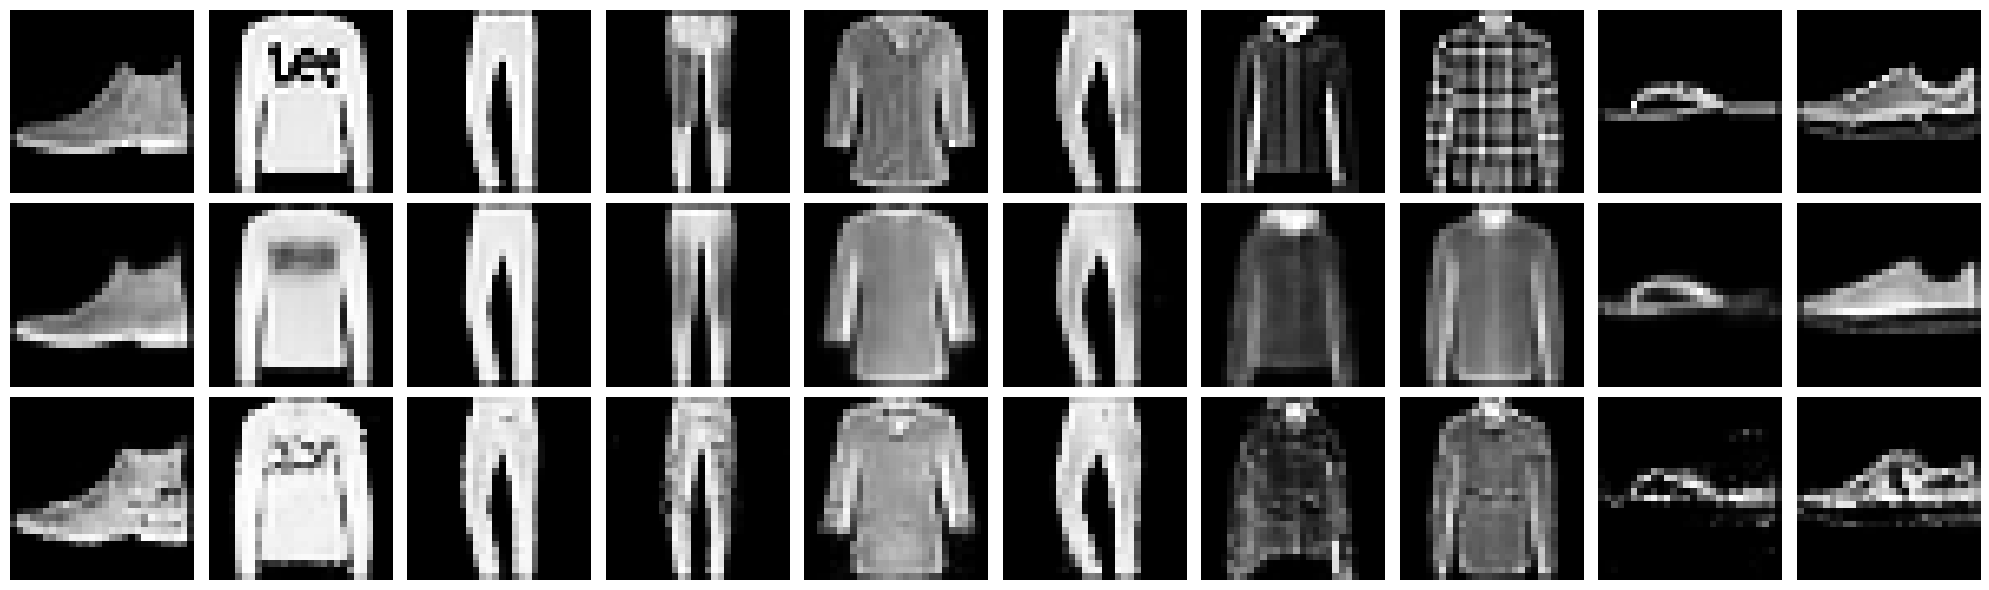

In [51]:

images, labels = next(iter(test_loader))
images = images.to(device)
labels = labels.to(device).long()

cvae_base = ConvCVAE(latent_dim=latent_dim, condition_dim=10).to(device)
cvae_base.load_state_dict(torch.load("final_cvae.pth", map_location=device))
cvae_base.eval()


ckpt = torch.load("final_cvae_gan.pth", map_location=device)
cvae_gan = ConvCVAE(latent_dim=ckpt["latent_dim"], condition_dim=10).to(device)
cvae_gan.load_state_dict(ckpt["cvae"])
cvae_gan.eval()

with torch.no_grad():
    recon_base, _, _ = cvae_base(images, labels)
    recon_gan,  _, _ = cvae_gan(images, labels)


images_np     = images.cpu().numpy().squeeze()
recon_base_np = recon_base.cpu().numpy().squeeze()
recon_gan_np  = recon_gan.cpu().numpy().squeeze()



import matplotlib.pyplot as plt

def image_comparison_3rows(real, rec1, rec2, n=10):
    plt.figure(figsize=(2*n, 6))
    for i in range(n):
        # row 1: real
        plt.subplot(3, n, i + 1)
        plt.imshow(real[i], cmap="gray")
        plt.axis("off")
        if i == 0: plt.ylabel("Real", fontsize=12)

        # row 2: CVAE
        plt.subplot(3, n, n + i + 1)
        plt.imshow(rec1[i], cmap="gray")
        plt.axis("off")
        if i == 0: plt.ylabel("CVAE", fontsize=12)

        # row 3: CVAE-GAN
        plt.subplot(3, n, 2*n + i + 1)
        plt.imshow(rec2[i], cmap="gray")
        plt.axis("off")
        if i == 0: plt.ylabel("CVAE-GAN", fontsize=12)

    plt.tight_layout()
    plt.show()

image_comparison_3rows(images_np, recon_base_np, recon_gan_np, n=10)


In [52]:


real = np.clip(images_np, 0, 1)
rec_base = np.clip(recon_base_np, 0, 1)
rec_gan  = np.clip(recon_gan_np, 0, 1)

psnr_base_list = [psnr(real[i], rec_base[i], data_range=1.0) for i in range(real.shape[0])]
psnr_gan_list  = [psnr(real[i], rec_gan[i],  data_range=1.0) for i in range(real.shape[0])]

print(f"PSNR mean (CVAE):     {np.mean(psnr_base_list):.2f} dB")
print(f"PSNR mean (CVAE-GAN): {np.mean(psnr_gan_list):.2f} dB")

# (tuỳ chọn) in vài ảnh đầu
print("First 10 PSNR CVAE    :", np.round(psnr_base_list[:10], 2))
print("First 10 PSNR CVAE-GAN:", np.round(psnr_gan_list[:10], 2))


PSNR mean (CVAE):     21.59 dB
PSNR mean (CVAE-GAN): 17.36 dB
First 10 PSNR CVAE    : [22.68 17.36 26.66 23.79 22.43 24.74 17.6  16.32 20.58 21.15]
First 10 PSNR CVAE-GAN: [17.49 14.52 19.62 17.99 16.95 21.   15.11 14.94 18.89 16.66]


**Commentaire:**
- CVAE (ligne 2) : les reconstructions sont plus lissées (peu de détails fins), la forme globale et les contours principaux restent donc proches de l’image réelle. La structure de l’objet est bien conservée.
- CVAE-GAN (ligne 3) : les reconstructions présentent souvent plus de contraste et de texture (aspect plus “marqué”), elles sont très spatialement variées.
- Le fait que PSNR moyen du CVAE est plus élevé que le PSNR moyen peut s’expliquer par le fait que le CVAE génère des images plus lisse, alors que le CVAE-GAN génère des images avec plus de détails et de textures, ce qui ne correspond pas à la nature du Fashion-MNIST. Par contre, ça ne veut pas dire que le CVAE-GAN est moins performant que le CVAE, ça veut juste dire que le CVAE-GAN génère des images plutôt créatives.


### 2 Comparaison des  generations : CVAE vs CVAE-GAN

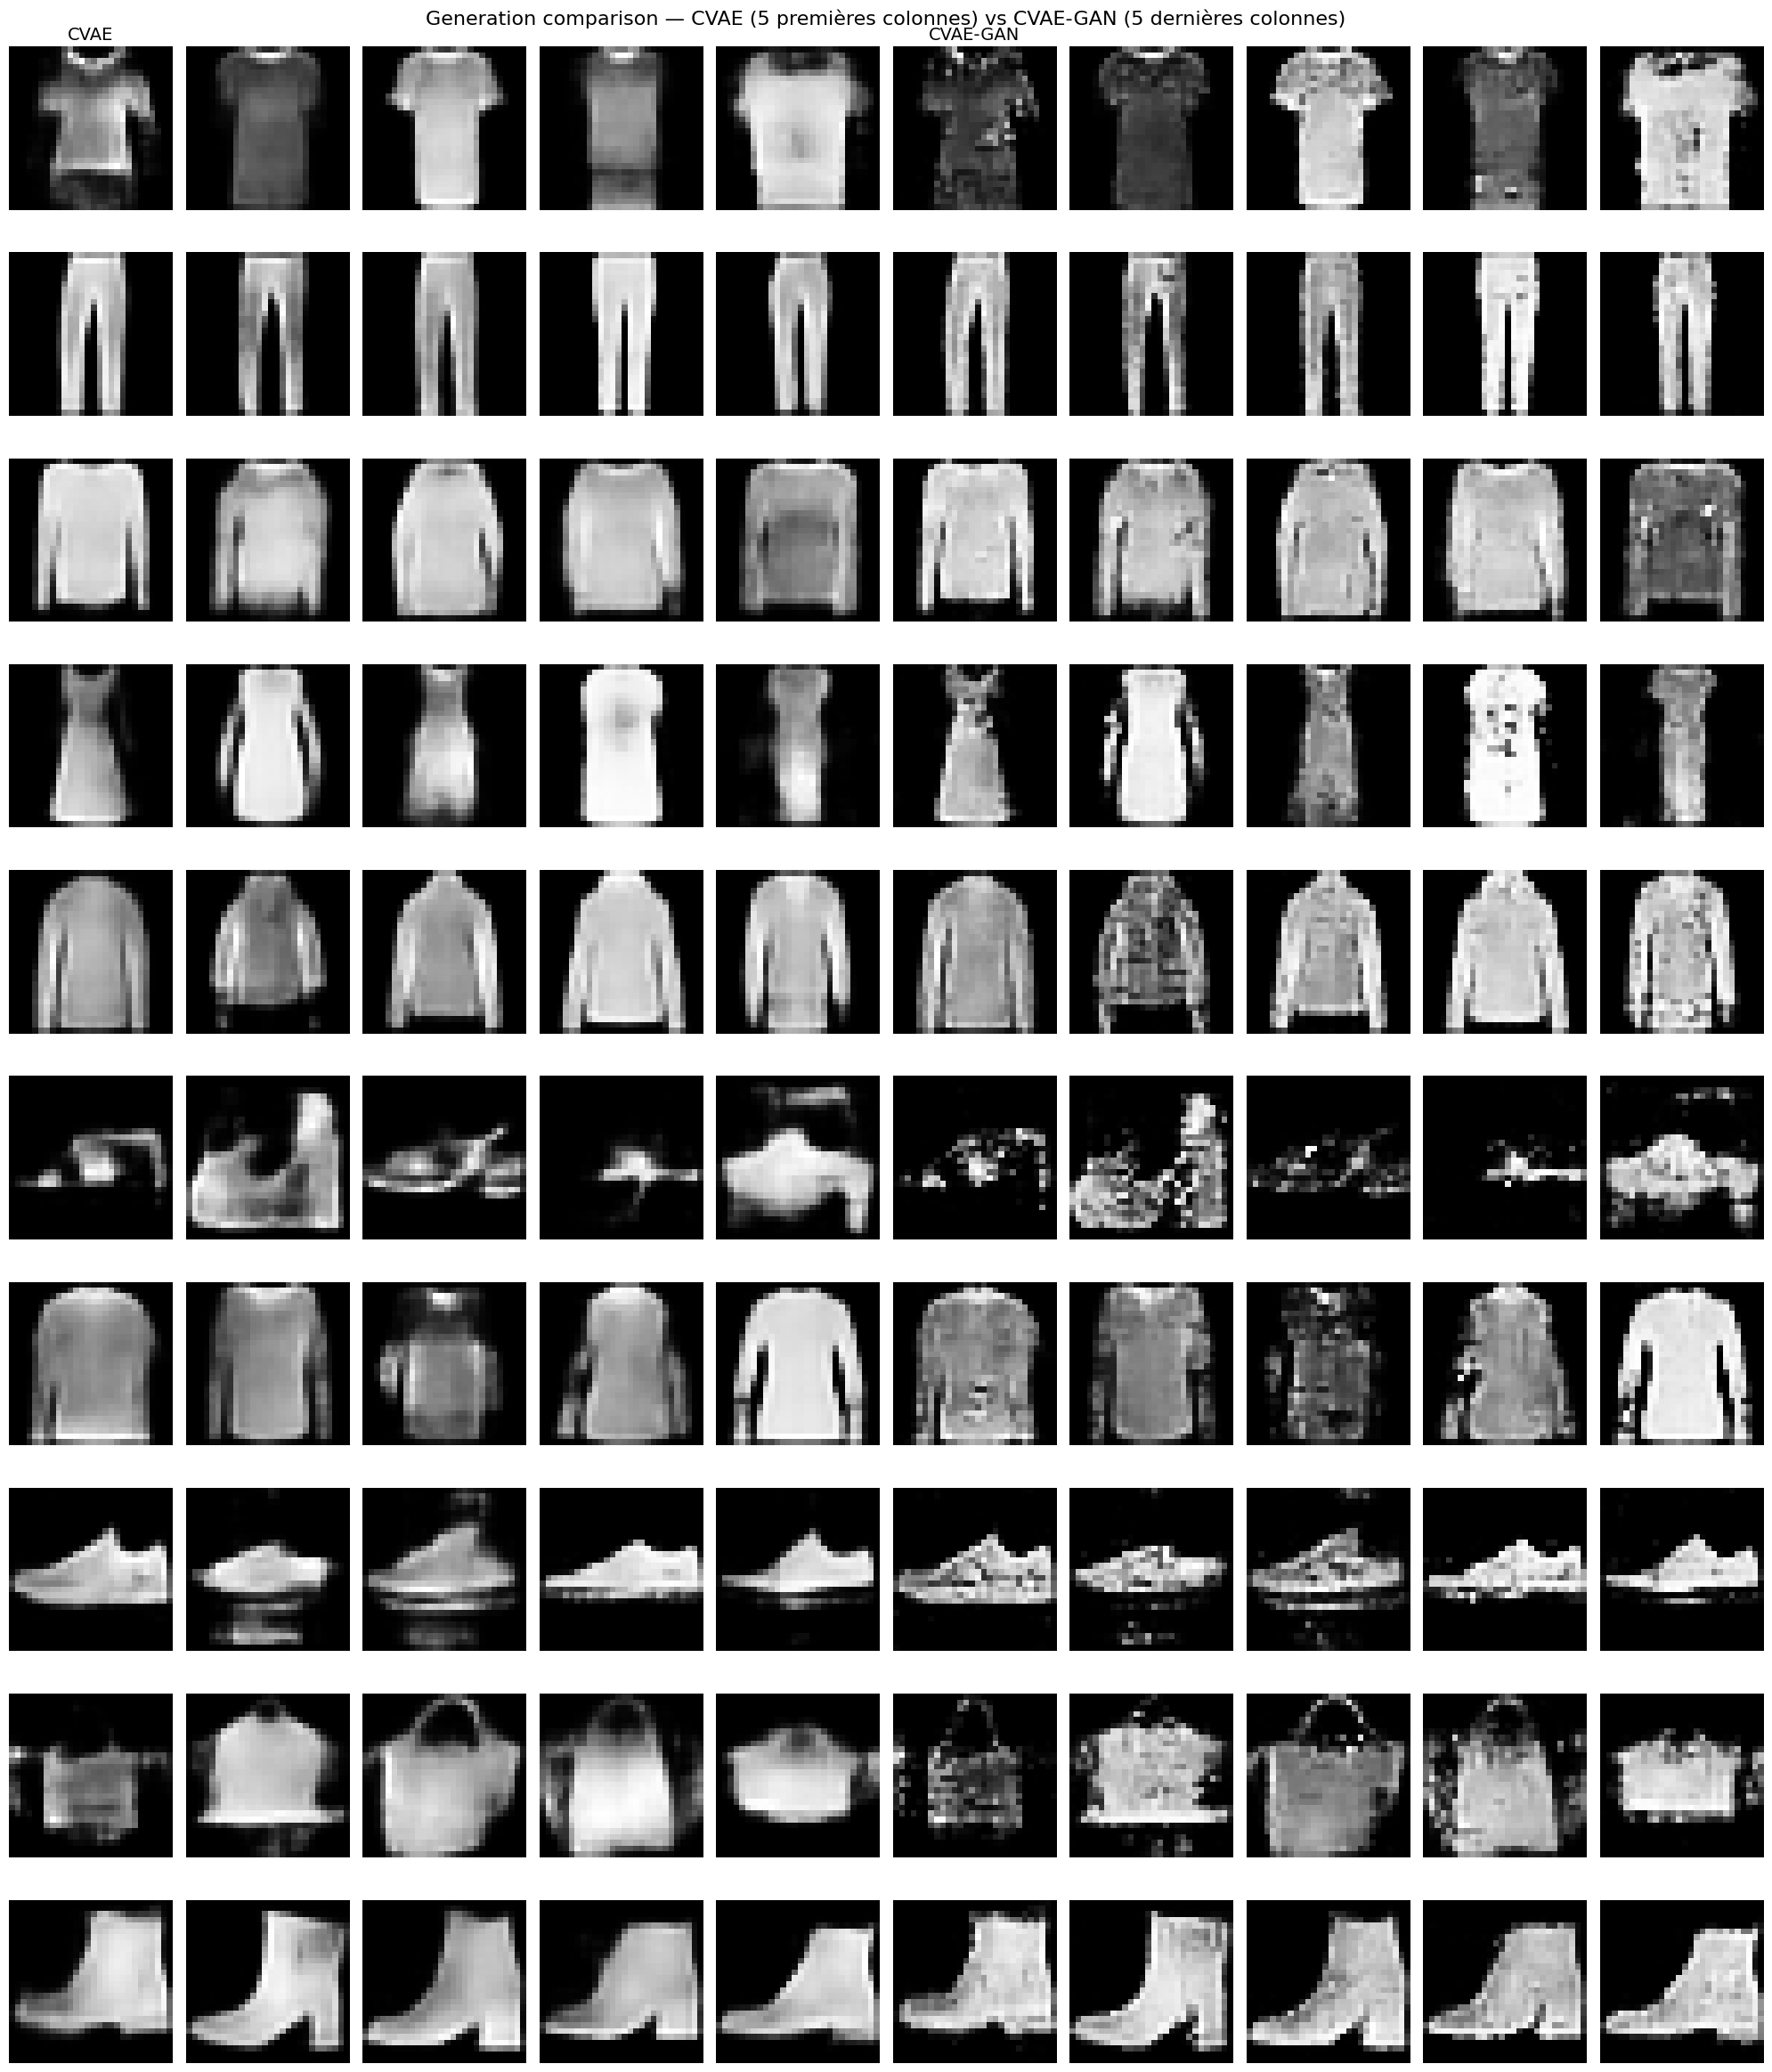

In [57]:


# --- Load CVAE base ---
cvae_base = ConvCVAE(latent_dim=latent_dim, condition_dim=10).to(device)
cvae_base.load_state_dict(torch.load("final_cvae.pth", map_location=device))
cvae_base.eval()

# --- Load CVAE-GAN (cvae part) ---
ckpt = torch.load("final_cvae_gan.pth", map_location=device)
cvae_gan = ConvCVAE(latent_dim=ckpt["latent_dim"], condition_dim=10).to(device)
cvae_gan.load_state_dict(ckpt["cvae"])
cvae_gan.eval()

class_names = [
    "T-shirt", "Pantalon", "Pull", "Robe", "Manteau",
    "Sandale", "Chemise", "Basket", "Sac", "Bottine"
]

@torch.no_grad()
def generate_compare_side_by_side(samples_per_class=5, seed=0):
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    fig, ax = plt.subplots(
        10, samples_per_class * 2,
        figsize=(2 * samples_per_class * 2, 24)
    )

    for class_idx in range(10):
        # same z for both models (fair comparison)
        z = torch.randn(samples_per_class, cvae_base.latent_dim, device=device)
        y = torch.full((samples_per_class,), class_idx, dtype=torch.long, device=device)

        gen_base = cvae_base.decode(z, y).cpu()
        gen_gan  = cvae_gan.decode(z, y).cpu()

        for i in range(samples_per_class):
            # left: CVAE
            ax[class_idx, i].imshow(gen_base[i].squeeze(), cmap="gray")
            ax[class_idx, i].axis("off")

            # right: CVAE-GAN
            ax[class_idx, i + samples_per_class].imshow(gen_gan[i].squeeze(), cmap="gray")
            ax[class_idx, i + samples_per_class].axis("off")

            # row label (class name)
            if i == 0:
                ax[class_idx, i].set_ylabel(
                    class_names[class_idx],
                    fontsize=12, rotation=0, labelpad=40
                )

        # headers (only first row)
        if class_idx == 0:
            ax[class_idx, 0].set_title("CVAE", fontsize=14)
            ax[class_idx, samples_per_class].set_title("CVAE-GAN", fontsize=14)

    plt.suptitle(f"Generation comparison — CVAE (5 premières colonnes) vs CVAE-GAN (5 dernières colonnes)", fontsize=16)
    plt.tight_layout()
    plt.show()

generate_compare_side_by_side(samples_per_class=5, seed=42)


*Commentaire sur les générations (par classe)*


En observant cette image, la tendance semble se confirmer :

- Pour les chaussures/sandales : CVAE-GAN offre généralement un rendu plus net (les contours des chaussures sont plus précis, avec un contraste plus marqué). Les chaussures/sandales ayant des formes distinctives et de nombreux « contours », l’application de GAN est donc avantageuse pour capturer ces détails.

- Pour les vêtements : les vêtements ont souvent peu de petits détails, CVAE-GAN ajoute des détails, ce qui rend les images générées loin des images réelles, CVAE produit des images plus lisses et donc plus proches des images réelles.



## Liens des ressources utilisées


 Les fichiers de poids se trouvent à l’adresse suivante : https://drive.google.com/drive/folders/1d_hw58Z4lV6RGWT9YcRm6MXrtrHXaPes

https://www.youtube.com/watch?v=W4peyiOaEFU&t=459s

https://www.codegenes.net/blog/cvae-pytorch/

https://pyro.ai/examples/cvae.html

https://nugg.ad/fr/glossaire-ia/autoencodeurs-variatoires-conditionnels/

https://beckham.nz/2023/04/27/conditional-vaes.html

https://github.com/Samgeorge2003/Conditional-Variational-Autoencoder-CVAE/blob/main/Conditional%20Variational%20Autoencoder%20(CVAE).ipynb

